# Learning ODE solutions using discretized PINN 

Consider an ODE IVP

$$
\begin{align*}
    x'(t) &= f(x) \\
    x(0) &= x_0 \\
\end{align*}
$$

To learn the solution, we will train a neural network function 
$$\tilde{x}(t) := x_0 + \sigma(w t) * F(t), $$
using the numerical residual loss (discretized PINN residual)
$$ \mathcal{J}_h[\tilde{x}] := \frac{1}{2} \int_{0}^{T} \| R_h[\tilde{x}](t) \| ^2  dt. $$

Our aim is to compare $\tilde{x}(t)$ learned with different numerical residuals: 

- Forward Euler $$ R_h[\tilde{x}](t) := \frac{\tilde{x}(t+h) - \tilde{x}(t)}{h} - f(\tilde{x}(t))$$

- Backward Euler $$ R_h[\tilde{x}](t) := \frac{\tilde{x}(t+h) - \tilde{x}(t)}{h} - f(\tilde{x}(t+h))$$

- Implicit Trapezoidal $$ R_h[\tilde{x}](t) := \frac{\tilde{x}(t+h) - \tilde{x}(t)}{h} - \frac{1}{2} \left( f(\tilde{x}(t)) + f(\tilde{x}(t+h)) \right) $$

- Implicit Midpoint $$ R_h[\tilde{x}](t) := \frac{\tilde{x}(t+h) - \tilde{x}(t)}{h} - f\left(\frac{\tilde{x}(t) + \tilde{x}(t+h)}{2}\right)$$

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np 
import matplotlib.pyplot as plt
from scipy.special import ellipj
print("Torch version:", torch.__version__)


# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:1")
print("Using device", device)

TORCH_DTYPE = torch.float64
NUMPY_DTYPE = np.float64

Torch version: 2.4.1+cu121
Using device cuda:1


## Set up

In [2]:
# Neural network to approximate the solution x_tilde(t)
class Net(nn.Module):
    def __init__(self, output_dim, x_0=None, enforce_ic=False, n_neurons=200, n_layers=2, output_stds=None):
        super(Net, self).__init__()
        fc = [nn.Linear(1, n_neurons), nn.ELU()]
        for _ in range(n_layers - 1):
            fc.extend([nn.Linear(n_neurons, n_neurons), nn.ELU()])
        self.fc = nn.Sequential(*fc, nn.Linear(n_neurons, output_dim))
        self.enforce_ic = enforce_ic
        if self.enforce_ic:
            if x_0 is None:
                raise ValueError("Initial condition x_0 must be provided")
            self.register_buffer("x_0", torch.tensor(x_0, dtype=TORCH_DTYPE))
            self.mult_w = nn.Parameter(torch.tensor(1.0), requires_grad=True)
        if output_stds is not None:
            self.register_buffer("output_stds", torch.tensor(output_stds, dtype=TORCH_DTYPE))

    def forward(self, t):
        out = self.fc(t)
        if hasattr(self, "output_stds"):
            out = out * self.output_stds
        if self.enforce_ic:
            # return self.x_0 + torch.tanh(self.mult_w * t) * out
            return self.x_0 + self.mult_w * t * out
        else:
            return out

# Residual functions for different numerical schemes
def residual_forward_euler(model, t, h, f):
    x_t = model(t)
    x_tp = model(t + h)
    x_tp_approx = x_t + h * f(x_t)
    return (x_tp - x_tp_approx) / h, (x_tp_approx, x_tp)

def residual_backward_euler(model, t, h, f):
    x_t = model(t)
    x_tp = model(t + h)
    x_tp_approx = x_t + h * f(x_tp)
    return (x_tp - x_tp_approx) / h, (x_tp_approx, x_tp)

def residual_implicit_trapezoidal(model, t, h, f):
    x_t = model(t)
    x_tp = model(t + h)
    x_tp_approx = x_t + 0.5 * h * (f(x_t) + f(x_tp))
    return (x_tp - x_tp_approx) / h, (x_tp_approx, x_tp)

def residual_implicit_midpoint(model, t, h, f):
    x_t = model(t)
    x_tp = model(t + h)
    x_tp_approx = x_t + h * f((x_t + x_tp) / 2)
    return (x_tp - x_tp_approx) / h, (x_tp_approx, x_tp)

def residual_velocity_verlet(model, t, h, f1, f2):
    x_t = model(t)
    x_tp = model(t + h)
    p_t, q_t = torch.chunk(x_t, 2, dim=-1)
    p_half = p_t + 0.5 * h * f1(q_t)
    q_next = q_t + h * f2(p_half)
    f_vv = torch.cat([0.5 * f1(q_t) + 0.5 * f1(q_next), f2(p_half)], dim=-1)
    x_tp_approx = x_t + h * f_vv
    return (x_tp - x_tp_approx) / h, (x_tp_approx, x_tp)

def arange_inclusive(start, end, step=1.0, epsilon=1e-9):
    # Check if (end - start) is close to a multiple of step
    if abs((end - start) / step - round((end - start) / step)) < epsilon:
        end += step  # Extend end by one step to include the original end
    return torch.arange(start, end, step, dtype=TORCH_DTYPE)

In [3]:
# Training function
def train(model, problem_config, loss_config, optim_config, log_config=None):

    f = problem_config["f"]
    f1 = problem_config.get("f1", None)
    f2 = problem_config.get("f2", None)
    def x_exact(t):
        t_np = t.cpu().numpy()
        x_t = problem_config["x_exact"](t_np, problem_config["x0"])
        return torch.tensor(x_t, device=device, dtype=TORCH_DTYPE)
    # x_exact = problem_config["x_exact"]
    ref_traj = problem_config.get("ref_traj", None)

    numerical_scheme = loss_config["numerical_scheme"]
    h = loss_config["h"]
    T = loss_config["T"]
    ODE_colloc_mode = loss_config["ODE_colloc_mode"]
    n_ODE = loss_config["n_ODE"]
    IC_colloc_mode = loss_config["IC_colloc_mode"]
    n_IC = loss_config["n_IC"]
    strength_ODE = loss_config["strength_ODE"]
    strength_IC = loss_config["strength_IC"]
    loss_fn = loss_config.get("loss_fn", None)
    if loss_fn is None:
        loss_fn = nn.MSELoss()

    optimizer_params = optim_config.get("optimizer_params", {})
    scheduler_params = optim_config.get("scheduler_params", {})
    min_iterations = optim_config.get("min_iterations", 0)
    iterations = optim_config["iterations"]
    threshold = optim_config["threshold"]

    if log_config is None:
        log_config = {"log_freq": 500, "plot_loss": True}
    log_freq = log_config["log_freq"]
    plot_loss = log_config["plot_loss"]

    def get_t_vals_ODE(t_vals_ODE):
        if t_vals_ODE is None:
            if ODE_colloc_mode == "random":
                return torch.rand(n_ODE, 1, device=device, dtype=TORCH_DTYPE) * T
            elif ODE_colloc_mode == "random2":
                return torch.rand(n_ODE, 1, device=device, dtype=TORCH_DTYPE) * 2 * T - T
            elif ODE_colloc_mode == "random3":
                return torch.randn(n_ODE, 1, device=device, dtype=TORCH_DTYPE) * T / 2
            # t0 = torch.tensor([0.], device=device).repeat(1, 1)
            # t_rand = torch.rand(batch_size, 1, device=device) * T
            # return torch.cat([t0, t_rand], dim=0) 
        return t_vals_ODE
    
    def get_t_vals_IC(t_vals_IC):
        if t_vals_IC is None:
            if IC_colloc_mode == "interval":
                return torch.rand(n_IC, 1, device=device, dtype=TORCH_DTYPE) * h
        return t_vals_IC

    model.to(device)

    if numerical_scheme == "velocity_verlet":
        residual_fn = lambda model, t: residual_velocity_verlet(model, t, h, f1, f2)
    else:
        residual_fn = lambda model, t: {
            "forward_euler": residual_forward_euler,
            "backward_euler": residual_backward_euler,
            "implicit_trapezoidal": residual_implicit_trapezoidal,
            "implicit_midpoint": residual_implicit_midpoint}[numerical_scheme](model, t, h, f)
    print(f"Training with {numerical_scheme}")

    # optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    optimizer = optim.LBFGS(model.parameters(), **optimizer_params)
    scheduler = optim.lr_scheduler.StepLR(optimizer, **scheduler_params)
    # scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, total_steps=iterations, **scheduler_params)

    if ODE_colloc_mode == "random":
        t_vals_ODE = None
        print(f"Using {n_ODE} random collocation points on [0, {T}] per iteration for ODE loss")
    elif ODE_colloc_mode == "random2":
        t_vals_ODE = None
        print(f"Using {n_ODE} random collocation points on [{-T}, {T}] per iteration for ODE loss")
    elif ODE_colloc_mode == "random3":
        t_vals_ODE = None
        print(f"Using {n_ODE} random collocation points sampled from Normal(0, {T/2}) per iteration for ODE loss")
    elif ODE_colloc_mode == "equidistant":
        t_vals_ODE = arange_inclusive(0, T, h).view(-1, 1).to(device)
        print(f"Using {len(t_vals_ODE)} equidistant collocation points on [0, {T}] per iteration for ODE loss")
    elif ODE_colloc_mode == "equidistant2":
        t_vals_ODE = arange_inclusive(-T, T, h).view(-1, 1).to(device)
        print(f"Using {len(t_vals_ODE)} equidistant collocation points on [{-T}, {T}] per iteration for ODE loss")
    else:
        raise ValueError("Invalid collocation mode for ODE loss")
    
    if IC_colloc_mode == "interval":
        t_vals_IC = None 
        print(f"Using {n_IC} random collocation points on [0, {h}] per iteration for IC loss")
    elif IC_colloc_mode == "pointwise":
        t_vals_IC = torch.tensor([0.], device=device, dtype=TORCH_DTYPE).view(-1, 1)
        print(f"Using 1 collocation point at 0 per iteration for IC loss")
    elif IC_colloc_mode == "ref_traj":
        if ref_traj is None:
            raise ValueError("Reference trajectory must be provided for IC loss")
        t_vals_IC = torch.tensor(ref_traj.times, device=device, dtype=TORCH_DTYPE).view(-1, 1)
        print(f"Using {len(t_vals_IC)} collocation points on [0, {h}] from reference trajectory per iteration for IC loss")
    else:
        raise ValueError("Invalid collocation mode for IC loss")
    
    loss_history = []
    loss_components = {"ODE_loss": None, "IC_loss": None}
    for iteration in range(iterations):

        _t_vals_ODE = get_t_vals_ODE(t_vals_ODE)
        _t_vals_IC = get_t_vals_IC(t_vals_IC)
        if IC_colloc_mode == "ref_traj":
            x_exact_vals = torch.tensor(ref_traj.states.convert_vx_to_pq(), device=device, dtype=TORCH_DTYPE)
        else:
            x_exact_vals = x_exact(_t_vals_IC)

        def closure():
            optimizer.zero_grad()
            if isinstance(loss_fn, nn.MSELoss):
                residual_vals, _ = residual_fn(model, _t_vals_ODE)
                ODE_loss = loss_fn(residual_vals, torch.zeros_like(residual_vals))
            else:
                _, (x_tp_approx, x_tp) = residual_fn(model, _t_vals_ODE)
                ODE_loss = loss_fn(x_tp_approx, x_tp) / h**2 
            IC_loss = loss_fn(model(_t_vals_IC), x_exact_vals)

            loss = strength_ODE * ODE_loss + strength_IC * IC_loss

            loss_components["ODE_loss"] = ODE_loss.item()
            loss_components["IC_loss"] = IC_loss.item()
            loss_components["loss"] = loss.item()

            loss.backward()
            return loss

        optimizer.step(closure)
        scheduler.step()

        if iteration % log_freq == 0:
            print(f"Iter {iteration}: \tlr = {scheduler.get_last_lr()[0]:.2e}, loss = {loss_components['loss']:.3e}, ", end="")
            print(f"ODE loss = {loss_components['ODE_loss']:.3e}, IC loss = {loss_components['IC_loss']:.3e}")
        
        loss_history.append(loss_components['loss'])

        if iteration >= min_iterations and loss_components['loss'] < threshold:
            break

    print(f"Final loss = {loss_components['loss']:.3e}")
    print(f"Final ODE loss = {loss_components['ODE_loss']:.3e}")
    print(f"Final IC loss = {loss_components['IC_loss']:.3e}")

    if plot_loss:
        plt.figure(figsize=(4, 2))
        plt.plot(loss_history)
        plt.yscale("log")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.show()


In [4]:
def fixed_point_solver(g, x0, tol, max_iter):
    """
    Solves x = g(x) using fixed-point iteration.
    
    Args:
    - g: A callable that takes a PyTorch tensor x and returns a tensor representing g(x).
    - x0: Initial guess for the fixed point as a PyTorch tensor.
    - tol: Tolerance for the stopping criterion based on the difference between iterations.
    - max_iter: Maximum number of iterations.
    
    Returns:
    - x: The fixed point such that x ≈ g(x).
    - success: Boolean indicating whether the method converged.
    """
    x = x0.clone().detach()  # Clone the initial guess so the original isn't modified
    
    for i in range(max_iter):
        # Compute g(x)
        x_new = g(x)
        
        # Check if the difference between the new and old value is below tolerance (convergence)
        error = torch.norm(x_new - x)
        if error < tol:
            print(f"Converged after {i+1} iterations. Error: {error}")
            return x_new, True
        
        # Update x to the new value
        x = x_new
    
    print(f"Warning: Did not converge after {max_iter} iterations. Error: {error}")
    return x, False

def newton_raphson_solver(f, x0, tol, max_iter):
    """
    Solves a system of nonlinear equations f(x) = 0 using the Newton-Raphson method.

    Parameters:
    - f: Function representing the system of equations. Should take a tensor x and return a tensor of the same shape.
    - x0: Initial guess (torch tensor).
    - tol: Tolerance for convergence (float).
    - max_iter: Maximum number of iterations (int).
    
    Returns:
    - x: Solution tensor (torch tensor).
    - success: Boolean indicating whether the method converged.
    """
    x = x0.clone().detach().requires_grad_(True)
    for i in range(max_iter):
        y = f(x)  # Evaluate f at x
        error = torch.norm(y)
        if error < tol:
            print(f"Converged after {i} iterations. Residual: {error}")
            return x, True  # Solution found

        # Compute Jacobian using autograd
        J = []
        for y_i in y:
            grad_y_i = torch.autograd.grad(y_i, x, retain_graph=True, create_graph=True)[0]
            J.append(grad_y_i)
        J = torch.stack(J)

        # Solve for delta_x (Newton step)
        delta_x = torch.linalg.solve(J, -y)
        x = (x + delta_x).detach().requires_grad_(True)

        if torch.norm(delta_x) < tol:
            print(f"Converged after {i+1} iterations. Residual: {torch.norm(f(x))}")
            return x, True  # Solution found

    print(f"Warning: Did not converge after {max_iter} iterations. Residual: {torch.norm(f(x))}")
    return x, False  # Did not converge within max_iter

# Step functions for different numerical schemes
def forward_euler_step(x_n, h, f):
    return x_n + h * f(x_n)

def backward_euler_step(x_n, h, f, tol=1e-6, max_iter=100):
    # return fixed_point_solver(lambda x: x_n + h * f(x), x_n, tol, max_iter)[0]
    return newton_raphson_solver(lambda x: x_n + h * f(x) - x, x_n, tol, max_iter)[0]

def implicit_trapezoidal_step(x_n, h, f, tol=1e-6, max_iter=100):
    # return fixed_point_solver(lambda x: x_n + 0.5 * h * (f(x_n) + f(x)), x_n, tol, max_iter)[0]
    return newton_raphson_solver(lambda x: x_n + 0.5 * h * (f(x_n) + f(x)) - x, x_n, tol, max_iter)[0]

def implicit_midpoint_step(x_n, h, f, tol=1e-6, max_iter=100):
    # return fixed_point_solver(lambda x: x_n + h * f(0.5 * (x_n + x)), x_n, tol, max_iter)[0]
    return newton_raphson_solver(lambda x: x_n + h * f(0.5 * (x_n + x)) - x, x_n, tol, max_iter)[0]

def velocity_verlet_step(x_n, h, f1, f2):
    p_n, q_n = torch.chunk(x_n, 2, dim=-1)
    p_half = p_n + 0.5 * h * f1(q_n)
    q_next = q_n + h * f2(p_half)
    p_next = p_half + 0.5 * h * f1(q_next)
    return torch.cat([p_next, q_next], dim=-1)

## Constant

$$
\begin{align*}
    x'(t) &= c \\
    x(0) &= x_0 \\
\end{align*}
$$

Solution: 
$$ x(t) = x_0 + ct $$


In [5]:
# Define the ODE: f(x) = c
def f_constant(x, c=1):
    return c

# Define the exact solution: x(t) = x(0) + ct
def x_exact_constant(t, x_0, c=1):
    return x_0 + c * t

# Evaluate the trained model
def test(model, problem_config, eval_config):

    f = problem_config["f"]
    def x_exact(t):
        x_t = problem_config["x_exact"](t, problem_config["x0"])
        return x_t

    n_eval = eval_config["n_eval"]
    t_range = eval_config["t_range"]
    show_numerical = eval_config["show_numerical"]
    numerical_scheme = eval_config["numerical_scheme"]
    h = eval_config["h"]
    plot_error = eval_config["plot_error"]

    residual_fn = lambda model, t: {
        "forward_euler": residual_forward_euler,
        "backward_euler": residual_backward_euler,
        "implicit_trapezoidal": residual_implicit_trapezoidal,
        "implicit_midpoint": residual_implicit_midpoint}[numerical_scheme](model, t, h, f)
    numerical_step = lambda x_n, h: {
        "forward_euler": forward_euler_step,
        "backward_euler": backward_euler_step,
        "implicit_trapezoidal": implicit_trapezoidal_step,
        "implicit_midpoint": implicit_midpoint_step}[numerical_scheme](x_n, h, f)

    t_vals = torch.linspace(t_range[0], t_range[1], n_eval, dtype=TORCH_DTYPE).reshape(-1, 1).to(device)
    residual_vals, _ = residual_fn(model, t_vals)
    residual_vals = residual_vals.detach().cpu().numpy()
    x_vals = model(t_vals).detach().cpu().numpy()
    t_vals = t_vals.cpu().numpy()
    x_exact_vals = x_exact(t_vals)
    
    if show_numerical:
        x_numerical_vals = [problem_config["x0"]]
        t_numerical_vals = [np.array([0.], dtype=NUMPY_DTYPE)]
        for _ in range(int(t_range[1] / h)):
            x_n = torch.tensor(x_numerical_vals[-1], dtype=TORCH_DTYPE).to(device)
            x_numerical_vals.append(numerical_step(x_n, h).detach().cpu().numpy())
            t_numerical_vals.append(t_numerical_vals[-1] + h)
        x_numerical_vals = np.array(x_numerical_vals)
        t_numerical_vals = np.array(t_numerical_vals)
            
    fig, axes = plt.subplots(3, 1, figsize=(6, 6))
    axes[0].plot(t_vals, x_exact_vals, "-", lw=1, color="k", label=r"Exact $x(t)$")
    axes[0].plot(t_vals, x_vals, "-", lw=1, color="r", label=r"Approximation $\tilde{x}(t)$")
    if show_numerical:
        axes[0].plot(t_numerical_vals, x_numerical_vals, ".-", lw=1, color="g", label=r"Numerical $x_n$")
    axes[0].set_xlabel("t")
    axes[0].set_ylabel("Solution x")
    axes[0].legend()
    
    axes[1].plot(t_vals, x_vals - x_exact_vals, "-", lw=1, color="r", label=r"$\tilde{x}(t) - x(t)$")
    if show_numerical:
        x_exact_vals = x_exact(t_numerical_vals)
        axes[1].plot(t_numerical_vals, x_exact_vals - x_numerical_vals, ".-", lw=1, color="g", label=r"$x(nh) - x_n$")
        x_vals_at_t_numerical = model(torch.tensor(t_numerical_vals).to(device)).detach().cpu().numpy()
        axes[1].plot(t_numerical_vals, x_vals_at_t_numerical - x_numerical_vals, ".-", lw=1, color="m", label=r"$\tilde{x}(nh) - x_n$")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("Error in x")
    axes[1].legend()

    axes[2].plot(t_vals, np.linalg.norm(residual_vals, axis=-1), "-", lw=1, color="b", label=r"$\| R_h[\tilde{x}](t)\|$")
    axes[2].set_xlabel("t")
    axes[2].set_ylabel("Residual")
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()

Training with implicit_trapezoidal
Using 1000 random collocation points on [-4.0, 4.0] per iteration for ODE loss
Using 100 random collocation points on [0, 1.0] per iteration for IC loss
Iter 0: 	lr = 1.00e+00, loss = 3.077e-05, ODE loss = 2.961e-05, IC loss = 1.169e-06
Iter 10: 	lr = 1.00e+00, loss = 2.344e-15, ODE loss = 2.326e-15, IC loss = 1.785e-17
Iter 20: 	lr = 1.00e+00, loss = 2.467e-15, ODE loss = 2.448e-15, IC loss = 1.907e-17
Iter 30: 	lr = 1.00e+00, loss = 2.292e-15, ODE loss = 2.277e-15, IC loss = 1.496e-17
Iter 40: 	lr = 1.00e+00, loss = 2.547e-15, ODE loss = 2.532e-15, IC loss = 1.532e-17
Iter 50: 	lr = 1.00e+00, loss = 2.395e-15, ODE loss = 2.376e-15, IC loss = 1.891e-17
Iter 60: 	lr = 1.00e+00, loss = 2.277e-15, ODE loss = 2.257e-15, IC loss = 1.921e-17
Iter 70: 	lr = 1.00e+00, loss = 2.670e-15, ODE loss = 2.652e-15, IC loss = 1.746e-17
Iter 80: 	lr = 1.00e+00, loss = 2.446e-15, ODE loss = 2.428e-15, IC loss = 1.830e-17
Iter 90: 	lr = 1.00e+00, loss = 2.531e-15, ODE l

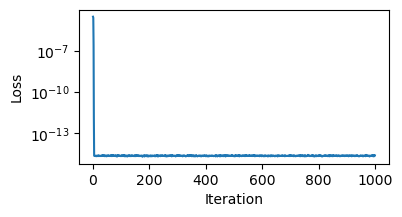

In [6]:
problem_config = {
    "f": lambda x: f_constant(x, c=1),
    "x_exact": lambda t, x0: x_exact_constant(t, x0, c=1),
    "x0": np.array([1.0], dtype=NUMPY_DTYPE)
}

loss_config = {
    "numerical_scheme": "implicit_trapezoidal",
    "h": 1.0,
    "T": 4.0,
    "ODE_colloc_mode": "random2",
    "n_ODE": 1000,
    "IC_colloc_mode": "interval",
    "n_IC": 100,
    "strength_ODE": 1.0,
    "strength_IC": 1.0
}

optim_config = {
    "iterations": 1000,
    "threshold": 1e-15,
    "optimizer_params": {"lr": 1., "max_iter": 5, "tolerance_grad": 1e-14, "tolerance_change": 1e-14},
    "scheduler_params": {"step_size": 10000, "gamma": 1.0},
}

log_config = {
    "log_freq": 10,
    "plot_loss": True
}

torch.manual_seed(1)
model = Net(output_dim=1, x_0=problem_config["x0"], enforce_ic=True, n_neurons=2)
model.to(device, dtype=TORCH_DTYPE)
train(model, problem_config, loss_config, optim_config, log_config)

In [7]:
model.mult_w.item()

1.17192684788459

Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 0.0


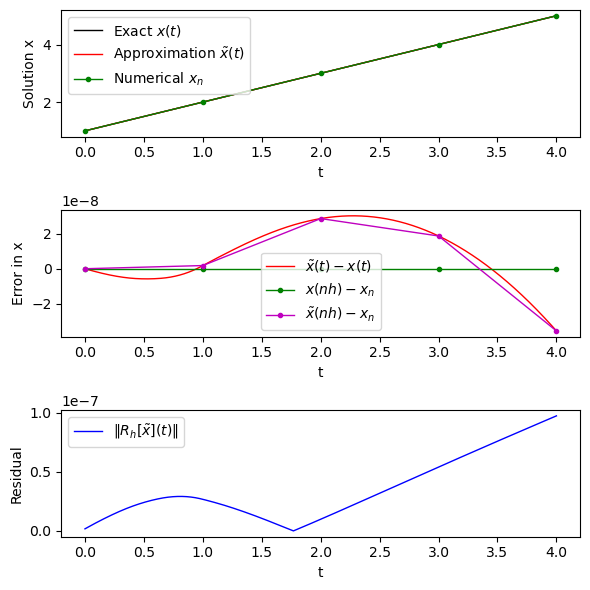

In [8]:
eval_config = {
    "n_eval": 10000,
    "t_range": [0, 4.0],
    "show_numerical": True,
    "numerical_scheme": "implicit_trapezoidal",
    "h": 1.0,
    "plot_error": False
}
test(model, problem_config, eval_config)

## Linear 

$$
\begin{align*}
    x'(t) &= c x \\
    x(0) &= x_0 \\
\end{align*}
$$

Solution: 
$$ x(t) = x_0 e^{ct}$$


In [25]:
# Define the ODE: f(x) = cx
def f_linear(x, c=1):
    return c * x

# Define the exact solution: x(t) = x(0) * exp(ct)
def x_exact_linear(t, x_0, c=1):
    return x_0 * np.exp(c * t)

def x_fake(t, x_0, c=1, h=0.5, numerical_scheme="forward_euler"):
    if numerical_scheme == "forward_euler":
        return x_0 * (1 + h*c)**(t/h)
    elif numerical_scheme == "backward_euler":
        return x_0 * (1 / (1 - h*c))**(t/h)
    elif numerical_scheme == "implicit_trapezoidal" or numerical_scheme == "implicit_midpoint":
        return x_0 * ((1 + 0.5*h*c) / (1 - 0.5*h*c))**(t/h)
    else:
        raise ValueError("Invalid numerical scheme")

# Evaluate the trained model
def test(model, problem_config, eval_config):

    f = problem_config["f"]
    def x_exact(t):
        x_t = problem_config["x_exact"](t, problem_config["x0"])
        return x_t

    n_eval = eval_config["n_eval"]
    t_range = eval_config["t_range"]
    show_numerical = eval_config["show_numerical"]
    numerical_scheme = eval_config["numerical_scheme"]
    h = eval_config["h"]
    plot_error = eval_config["plot_error"]
    def x_fake(t):
        x_t = eval_config["x_fake"](t, problem_config["x0"])
        return x_t
    x_fake_label = eval_config["x_fake_label"]
    error_ylim = eval_config["error_ylim"]

    residual_fn = lambda model, t: {
        "forward_euler": residual_forward_euler,
        "backward_euler": residual_backward_euler,
        "implicit_trapezoidal": residual_implicit_trapezoidal,
        "implicit_midpoint": residual_implicit_midpoint}[numerical_scheme](model, t, h, f)
    numerical_step = lambda x_n, h: {
        "forward_euler": forward_euler_step,
        "backward_euler": backward_euler_step,
        "implicit_trapezoidal": implicit_trapezoidal_step,
        "implicit_midpoint": implicit_midpoint_step}[numerical_scheme](x_n, h, f)

    def dxdt(t):
        return torch.func.vmap(torch.func.jacrev(model, argnums=0))(t).squeeze(-1)

    t_vals = torch.linspace(t_range[0], t_range[1], n_eval).reshape(-1, 1).to(device)
    residual_vals = residual_fn(model, t_vals).detach().cpu().numpy()
    x_vals = model(t_vals).detach().cpu().numpy()
    exact_residual_vals = (dxdt(t_vals) - f(t_vals)).detach().cpu().numpy()
    t_vals = t_vals.cpu().numpy()
    x_exact_vals = x_exact(t_vals)
    
    if show_numerical:
        x_numerical_vals = [problem_config["x0"]]
        t_numerical_vals = [np.array([0.], dtype=np.float32)]
        for _ in range(int(t_range[1] / h)):
            x_n = torch.tensor(x_numerical_vals[-1]).to(device)
            x_numerical_vals.append(numerical_step(x_n, h).detach().cpu().numpy())
            t_numerical_vals.append(t_numerical_vals[-1] + h)
        x_numerical_vals = np.array(x_numerical_vals)
        t_numerical_vals = np.array(t_numerical_vals)
            
    fig, axes = plt.subplots(4, 1, figsize=(9, 8))
    # axes[0].plot(t_vals, x_exact_vals, "-", lw=1, color="k", label=r"Exact $x(t)$")
    axes[0].plot(t_vals, x_vals, "-", lw=1, color="r", label=r"Approximation $\tilde{x}(t)$")
    if show_numerical:
        axes[0].plot(t_numerical_vals, x_numerical_vals, ".-", lw=1, color="g", label=r"Numerical $x_n$")
    axes[0].plot(t_vals, x_fake(t_vals), "--", lw=1, color="k", label=r"Possible minimizer $\hat{x}(t)$"+x_fake_label)
    axes[0].set_xlabel("t")
    axes[0].set_ylabel("Solution x")
    axes[0].legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")
    
    # axes[1].plot(t_vals, np.linalg.norm(x_vals - x_exact_vals, axis=-1), "-", lw=1, color="r", label=r"$\| \tilde{x}(t) - x(t)\|$")
    if show_numerical:
        x_exact_vals = x_exact(t_numerical_vals)
        # axes[1].plot(t_numerical_vals, x_numerical_vals - x_exact_vals, ".-", lw=1, color="g", label=r"$x_n - x(nh)$")
        x_vals_at_t_numerical = model(torch.tensor(t_numerical_vals).to(device)).detach().cpu().numpy()
        axes[1].plot(t_numerical_vals, np.linalg.norm(x_numerical_vals - x_vals_at_t_numerical, axis=-1), ".-", lw=1, color="g", label=r"$\|\tilde{x}(nh) - x_n\|$")
    axes[1].plot(t_vals, np.linalg.norm(x_fake(t_vals) - x_vals, axis=-1), "--", lw=1, color="k", label=r"$\| \tilde{x}(t)-\hat{x}(t) \|$")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("Error in x")
    axes[1].set_ylim(error_ylim)
    axes[1].legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")

    axes[2].plot(t_vals, np.linalg.norm(residual_vals, axis=-1), "-", lw=1, color="b", label=r"$\| R_h[\tilde{x}](t) \|$")
    axes[2].set_xlabel("t")
    axes[2].set_ylabel("Residual")
    axes[2].legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")
    
    axes[3].plot(t_vals, np.linalg.norm(exact_residual_vals, axis=-1), "-", lw=1, color="b", label=r"$\| d\tilde{x}(t) /dt - f(\tilde{x}(t)) \|$")
    # axes[3].plot(t_vals, np.exp(t_vals), "-", lw=1, color="k", label=r"$\exp(t)$")
    # axes[3].plot(t_vals, (1.5)**(t_vals/0.5 -1) / 0.5, "--", lw=1, color="k", label=r"$deriv$")
    axes[3].set_xlabel("t")
    axes[3].set_ylabel("Exact Residual")
    axes[3].legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")
    
    plt.tight_layout()
    plt.show()

Training with forward_euler
Using 1000 random collocation points sampled from Normal(0, 1.0) per iteration for ODE loss
Using 100 random collocation points on [0, 0.5] per iteration for IC loss
Iter 0: 	lr = 1.00e-03, loss = 1.097e+00, ODE loss = 1.097e+00, IC loss = 1.018e-01
Iter 100: 	lr = 1.00e-03, loss = 1.386e-01, ODE loss = 1.386e-01, IC loss = 4.342e-03
Iter 200: 	lr = 1.00e-03, loss = 8.244e-02, ODE loss = 8.244e-02, IC loss = 6.925e-04
Iter 300: 	lr = 1.00e-03, loss = 1.014e-02, ODE loss = 1.014e-02, IC loss = 5.313e-04
Iter 400: 	lr = 1.00e-03, loss = 9.978e-03, ODE loss = 9.978e-03, IC loss = 1.220e-03
Iter 500: 	lr = 1.00e-03, loss = 9.409e-03, ODE loss = 9.409e-03, IC loss = 1.569e-03
Iter 600: 	lr = 1.00e-03, loss = 1.562e-02, ODE loss = 1.562e-02, IC loss = 3.548e-03
Iter 700: 	lr = 1.00e-03, loss = 1.431e-03, ODE loss = 1.431e-03, IC loss = 3.382e-05
Iter 800: 	lr = 1.00e-03, loss = 9.886e-03, ODE loss = 9.886e-03, IC loss = 4.070e-04
Iter 900: 	lr = 1.00e-03, loss = 1

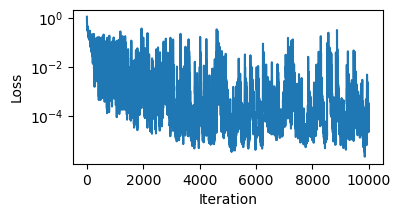

In [30]:
problem_config = {
    "f": lambda x: f_linear(x, c=1),
    # "x_exact": lambda t, x0: x_exact_linear(t, x0, c=-1),
    "x_exact": lambda t, x0: x_fake(t, x0, c=1, h=0.5, numerical_scheme="forward_euler"),
    "x0": np.array([1.0], dtype=np.float32)
}

loss_config = {
    "numerical_scheme": "forward_euler",
    "h": 0.5,
    "T": 2.0,
    "ODE_colloc_mode": "random3",
    "n_ODE": 1000,
    "IC_colloc_mode": "interval",
    "n_IC": 100,
    "strength_ODE": 1.0,
    "strength_IC": 0.0
}

optim_config = { 
    "lr": 1e-3,
    "weight_decay": 0.0,
    "min_iterations": 500,
    "iterations": 10000,
    "scheduler_params": {"step_size": 10000, "gamma": 1.0},
    # "scheduler_params": {"pct_start": 0.1},
    "threshold": 5e-7
}

log_config = {
    "log_freq": 100,
    "plot_loss": True
}

torch.manual_seed(1)
model = Net(output_dim=1, x_0=problem_config["x0"], enforce_ic=True)
train(model, problem_config, loss_config, optim_config, log_config)

Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 2.384185791015625e-07
Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 4.76837158203125e-07


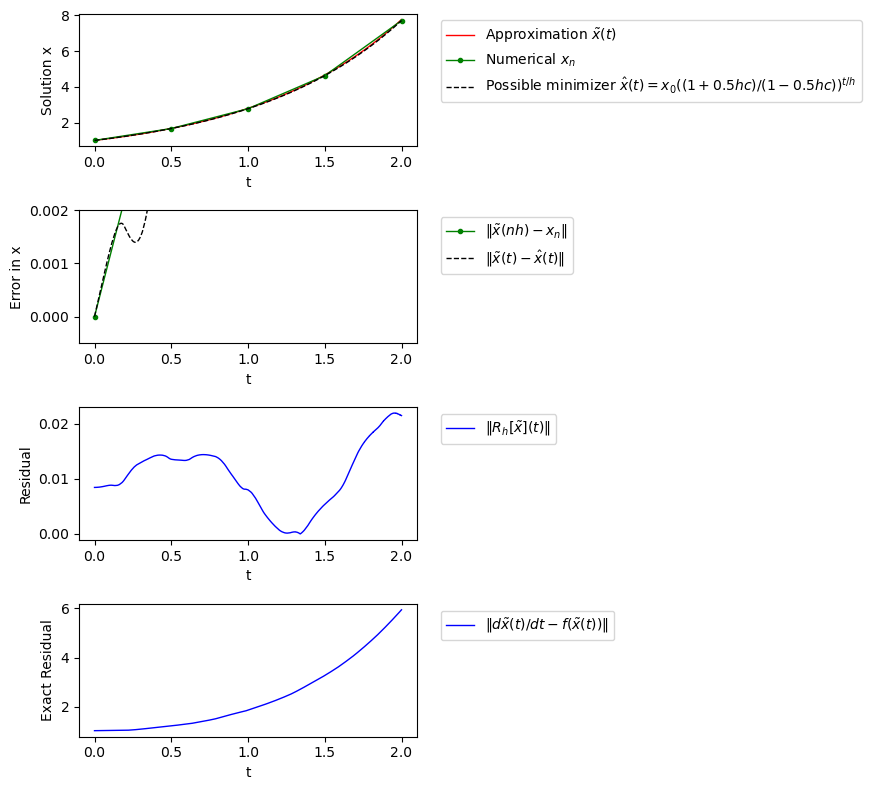

In [48]:
problem_config = {
    "x0": np.array([1.0], dtype=np.float32),
    "f": lambda x: f_linear(x, c=1),
    "x_exact": lambda t, x0: x_exact_linear(t, x0, c=1),
}

eval_config = {
    "n_eval": 10000,
    "t_range": [0, 2.0],
    "show_numerical": True,
    "numerical_scheme": "implicit_trapezoidal",
    "h": 0.5,
    "plot_error": False,
    "x_fake": lambda t, x0: x_fake(t, x0, c=1, h=0.5, numerical_scheme="implicit_trapezoidal"),
    "x_fake_label": r"$=x_0(1+hc)^{t/h}$",
    "x_fake_label": r"$=x_0((1+0.5hc)/(1-0.5hc))^{t/h}$",
    "error_ylim": [-0.5e-3, 2e-3]
}

test(model, problem_config, eval_config)

Training with forward_euler
Using 1000 random collocation points sampled from Normal(0, 1.0) per iteration for ODE loss
Using 100 random collocation points on [0, 0.5] per iteration for IC loss
Iter 0: 	lr = 1.00e-03, loss = 9.173e-01, ODE loss = 8.655e-01, IC loss = 5.179e-02
Iter 500: 	lr = 1.00e-03, loss = 2.951e-03, ODE loss = 2.774e-03, IC loss = 1.768e-04
Iter 1000: 	lr = 1.00e-03, loss = 1.102e-03, ODE loss = 1.035e-03, IC loss = 6.639e-05
Iter 1500: 	lr = 1.00e-03, loss = 2.614e-04, ODE loss = 2.575e-04, IC loss = 3.895e-06
Iter 2000: 	lr = 1.00e-03, loss = 3.811e-02, ODE loss = 3.811e-02, IC loss = 8.021e-07
Iter 2500: 	lr = 1.00e-03, loss = 1.105e-03, ODE loss = 9.089e-04, IC loss = 1.960e-04
Iter 3000: 	lr = 1.00e-03, loss = 3.514e-03, ODE loss = 3.513e-03, IC loss = 1.002e-06
Iter 3500: 	lr = 1.00e-03, loss = 6.730e-04, ODE loss = 6.713e-04, IC loss = 1.729e-06
Iter 4000: 	lr = 1.00e-03, loss = 1.166e-03, ODE loss = 1.164e-03, IC loss = 1.863e-06
Iter 4500: 	lr = 1.00e-03, 

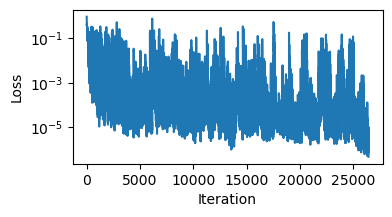

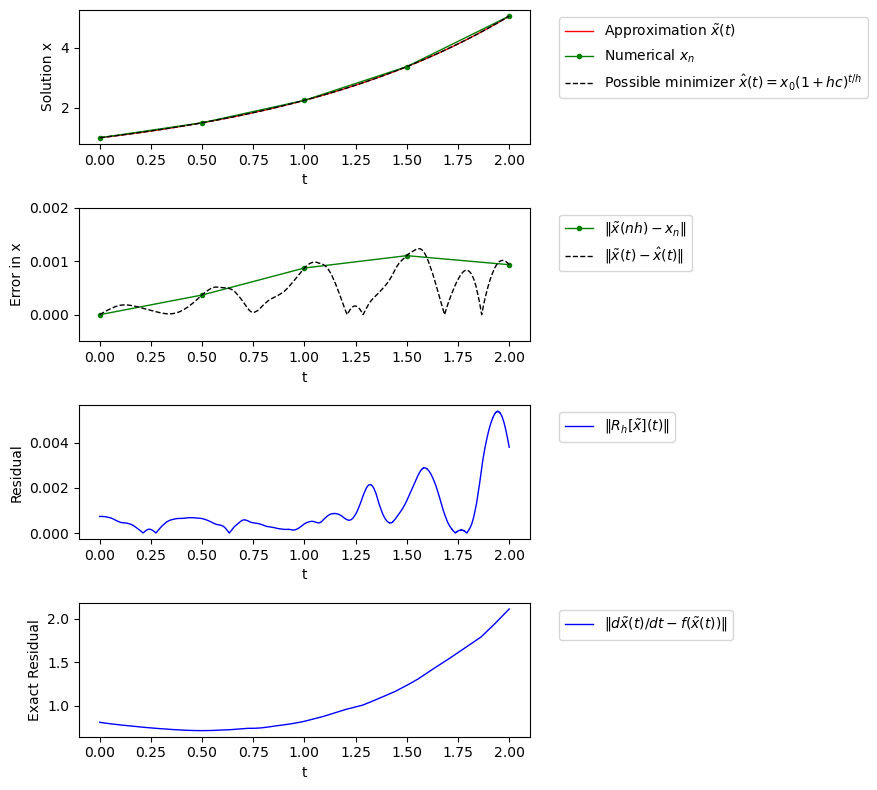

Training with forward_euler
Using 1000 random collocation points sampled from Normal(0, 1.0) per iteration for ODE loss
Using 100 random collocation points on [0, 0.5] per iteration for IC loss
Iter 0: 	lr = 1.00e-03, loss = 8.707e-01, ODE loss = 8.655e-01, IC loss = 5.179e-02
Iter 500: 	lr = 1.00e-03, loss = 3.252e-03, ODE loss = 3.241e-03, IC loss = 1.154e-04
Iter 1000: 	lr = 1.00e-03, loss = 6.335e-04, ODE loss = 6.221e-04, IC loss = 1.137e-04
Iter 1500: 	lr = 1.00e-03, loss = 2.590e-04, ODE loss = 2.558e-04, IC loss = 3.183e-05
Iter 2000: 	lr = 1.00e-03, loss = 3.202e-02, ODE loss = 3.202e-02, IC loss = 1.631e-06
Iter 2500: 	lr = 1.00e-03, loss = 7.468e-04, ODE loss = 7.242e-04, IC loss = 2.259e-04
Iter 3000: 	lr = 1.00e-03, loss = 3.943e-03, ODE loss = 3.943e-03, IC loss = 1.629e-06
Iter 3500: 	lr = 1.00e-03, loss = 4.703e-04, ODE loss = 4.695e-04, IC loss = 8.306e-06
Iter 4000: 	lr = 1.00e-03, loss = 6.164e-04, ODE loss = 6.163e-04, IC loss = 1.451e-06
Iter 4500: 	lr = 1.00e-03, 

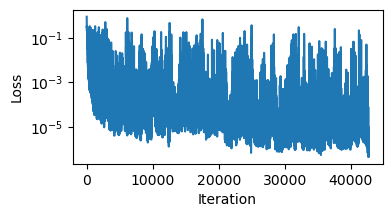

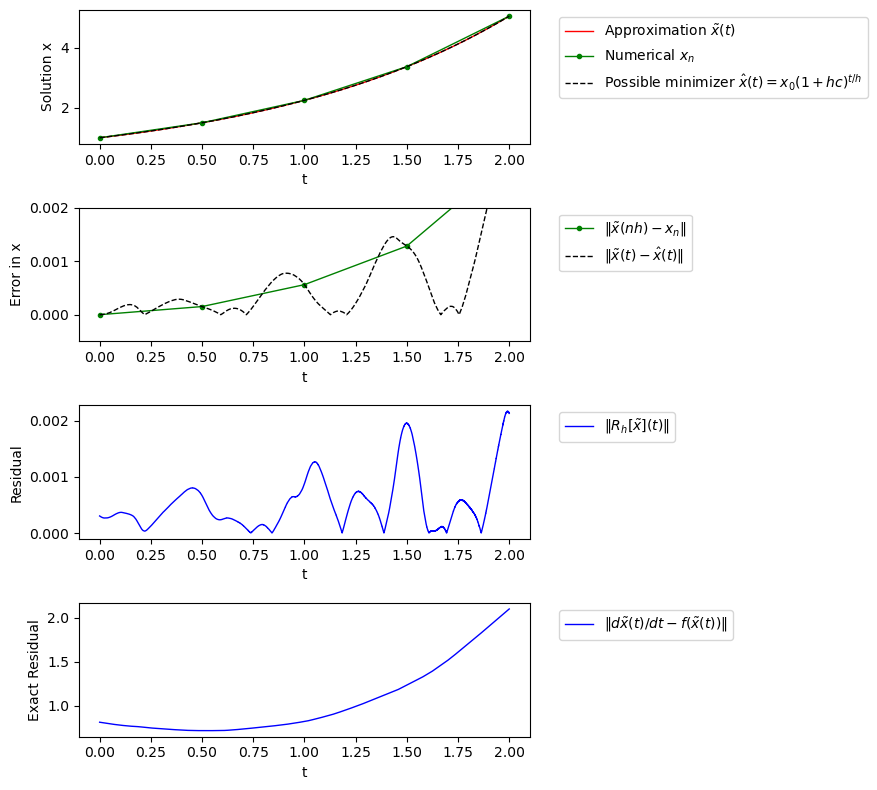

Training with forward_euler
Using 1000 random collocation points sampled from Normal(0, 1.0) per iteration for ODE loss
Using 100 random collocation points on [0, 0.5] per iteration for IC loss
Iter 0: 	lr = 1.00e-03, loss = 8.655e-01, ODE loss = 8.655e-01, IC loss = 5.179e-02
Iter 500: 	lr = 1.00e-03, loss = 3.317e-03, ODE loss = 3.317e-03, IC loss = 1.189e-04
Iter 1000: 	lr = 1.00e-03, loss = 6.027e-04, ODE loss = 6.027e-04, IC loss = 1.491e-04
Iter 1500: 	lr = 1.00e-03, loss = 2.535e-04, ODE loss = 2.535e-04, IC loss = 5.796e-05
Iter 2000: 	lr = 1.00e-03, loss = 3.189e-02, ODE loss = 3.189e-02, IC loss = 6.374e-06
Iter 2500: 	lr = 1.00e-03, loss = 7.599e-04, ODE loss = 7.599e-04, IC loss = 2.433e-04
Iter 3000: 	lr = 1.00e-03, loss = 4.326e-03, ODE loss = 4.326e-03, IC loss = 1.963e-06
Iter 3500: 	lr = 1.00e-03, loss = 4.953e-04, ODE loss = 4.953e-04, IC loss = 2.466e-06
Iter 4000: 	lr = 1.00e-03, loss = 5.981e-04, ODE loss = 5.981e-04, IC loss = 1.686e-05
Iter 4500: 	lr = 1.00e-03, 

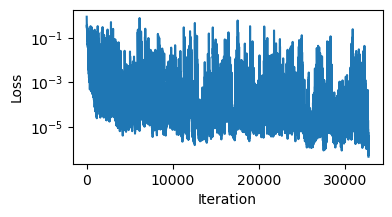

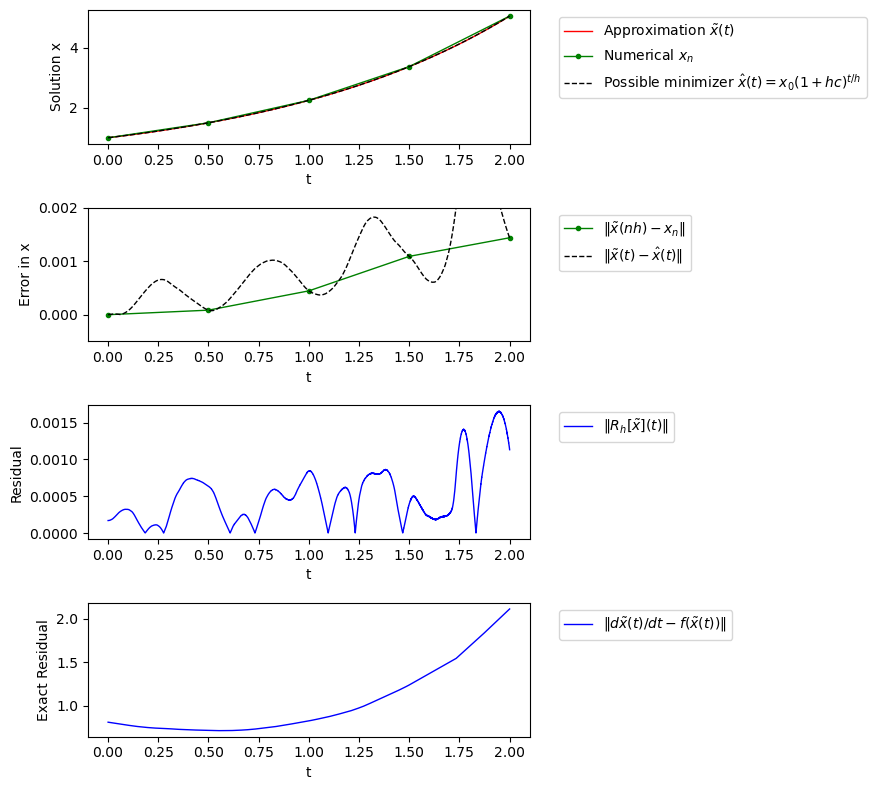

In [120]:
problem_config = {
    "f": lambda x: f_linear(x, c=1),
    # "x_exact": lambda t, x0: x_exact_linear(t, x0, c=-1),
    "x_exact": lambda t, x0: x_fake(t, x0, c=1, h=0.5),
    "x0": np.array([1.0], dtype=np.float32)
}

loss_config = {
    "numerical_scheme": "forward_euler",
    "h": 0.5,
    "T": 2.0,
    "ODE_colloc_mode": "random3",
    "n_ODE": 1000,
    "IC_colloc_mode": "interval",
    "n_IC": 100,
    "strength_ODE": 1.0,
    "strength_IC": 0.0
}

optim_config = {
    "lr": 1e-3,
    "weight_decay": 0.0,
    "min_iterations": 5000,
    "iterations": 100000,
    "scheduler_params": {"step_size": 1000, "gamma": 1.0},
    "threshold": 5e-7
}

for strength_IC in [1.0, 0.1, 0.0]:
    loss_config["strength_IC"] = strength_IC
    torch.manual_seed(0)
    model = Net(output_dim=1, x_0=problem_config["x0"], enforce_ic=True)
    train(model, problem_config, loss_config, optim_config)

    eval_config = {
        "n_eval": 10000,
        "t_range": [0, 2.0],
        "show_numerical": True,
        "numerical_scheme": "forward_euler",
        "h": 0.5,
        "plot_error": False,
        "x_fake": lambda t, x0: x_fake(t, x0, c=1, h=0.5),
        "x_fake_label": r"$=x_0(1+hc)^{t/h}$",
        "error_ylim": [-0.5e-3, 2e-3]
    }

    test(model, problem_config, eval_config)

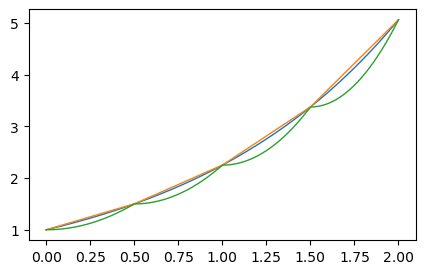

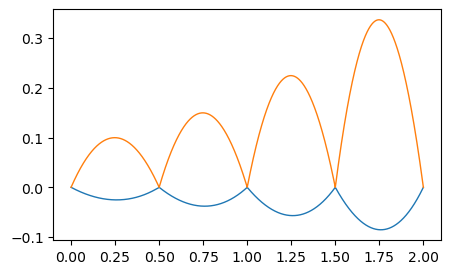

In [130]:
def x_fake1(t, x0, c=1, h=0.5):
    return x0 * (1 + h*c)**(t/h)

def x_fake2(t, x0, c=1, h=0.5):
    def x_eps(eps):
        return x0 * (1 + eps*c)
    return (1 + h*c)**(t // h) * x_eps(t % h)

def x_fake3(t, x0, c=1, h=0.5):
    def x_eps(eps):
        return x0 * (1 + eps**2 * c/h)
    return (1 + h*c)**(t // h) * x_eps(t % h)

c = 1
h = 0.5
T = 2.0

tt = np.linspace(0, T, 10000)

plt.figure(figsize=(5, 3))
plt.plot(tt, x_fake1(tt, 1, c, h), "-", lw=1, label="x_fake1")
plt.plot(tt, x_fake2(tt, 1, c, h), "-", lw=1, label="x_fake2")
plt.plot(tt, x_fake3(tt, 1, c, h), "-", lw=1, label="x_fake3")
plt.show()

plt.figure(figsize=(5, 3))
plt.plot(tt, x_fake1(tt, 1, c, h)-x_fake2(tt, 1, c, h), "-", lw=1, label="x_fake1 - x_fake2")
plt.plot(tt, x_fake1(tt, 1, c, h)-x_fake3(tt, 1, c, h), "-", lw=1, label="x_fake1 - x_fake3")
plt.show()

## Harmonic Oscillator 

$$H(p,q) = \frac{1}{2}p^2 + \frac{1}{2}q^2 $$ 

$$\frac{d}{dt} \begin{bmatrix} p \\ q \end{bmatrix} = \begin{bmatrix} -q \\ p \end{bmatrix}$$

Solution: 
$$\begin{bmatrix} p(t) \\ q(t) \end{bmatrix} = \begin{bmatrix} \cos(t) & -\sin(t) \\ \sin(t) & \cos(t) \end{bmatrix}
\begin{bmatrix} p(0) \\ q(0) \end{bmatrix} $$


In [13]:
# Define the ODE
def f_harmonic(x):
    p, q = torch.chunk(x, 2, dim=-1)
    return torch.cat([-q, p], dim=-1)

def f1_harmonic(q):
    return -q

def f2_harmonic(p):
    return p

# Define the exact solution
def x_exact_harmonic(t, x_0):
    p_0, q_0 = x_0[..., 0:1], x_0[..., 1:2]
    p_t = p_0 * np.cos(t) - q_0 * np.sin(t)
    q_t = p_0 * np.sin(t) + q_0 * np.cos(t)
    return np.concatenate([p_t, q_t], axis=-1)

def x_fake_harmonic(t, x_0, h, numerical_scheme="forward_euler"):
    p_0, q_0 = x_0[..., 0:1], x_0[..., 1:2]
    if numerical_scheme == "forward_euler":
        arctan_h = np.arctan(h)
        cost = np.cos(t * arctan_h/h)
        sint = np.sin(t * arctan_h/h)
        ampifier = np.sqrt(1 + h**2) 
        p_t = (p_0 * cost - q_0 * sint) * ampifier**(t/h)
        q_t = (p_0 * sint + q_0 * cost) * ampifier**(t/h)
    elif numerical_scheme == "backward_euler":
        arctan_h = np.arctan(h)
        cost = np.cos(t * arctan_h/h)
        sint = np.sin(t * arctan_h/h)
        ampifier = 1 / np.sqrt(1 + h**2) 
        p_t = (p_0 * cost - q_0 * sint) * ampifier**(t/h)
        q_t = (p_0 * sint + q_0 * cost) * ampifier**(t/h)
    elif numerical_scheme == "implicit_trapezoidal" or numerical_scheme == "implicit_midpoint":
        arctan_halfh = np.arctan(0.5*h)
        cost = np.cos(t * 2 * arctan_halfh/h)
        sint = np.sin(t * 2 * arctan_halfh/h)
        p_t = (p_0 * cost - q_0 * sint)
        q_t = (p_0 * sint + q_0 * cost)
    elif numerical_scheme == "velocity_verlet":
        c1 = np.sqrt(1 - 0.25 * h**2)
        c2 = np.arcsin(h * c1)
        cost = np.cos(t * c2/h)
        sint = np.sin(t * c2/h)
        p_t = (p_0 * cost - c1 * q_0 * sint) 
        q_t = (p_0 * sint + c1 * q_0 * cost) / c1
    else:
        raise ValueError("Invalid numerical scheme")
    return np.concatenate([p_t, q_t], axis=-1)

# Define the Hamiltonian
def H_harmonic(x):
    p, q = x[..., 0:1], x[..., 1:2]
    return 0.5 * (p ** 2 + q ** 2)

In [5]:
# Evaluate the trained model
def test(model, problem_config, eval_config):
    
    f = problem_config["f"]
    f1 = problem_config["f1"]
    f2 = problem_config["f2"]
    def x_exact(t):
        x_t = problem_config["x_exact"](t, problem_config["x0"])
        return x_t
    H = problem_config["H"]

    n_eval = eval_config["n_eval"]
    t_range = eval_config["t_range"]
    show_numerical = eval_config["show_numerical"]
    numerical_scheme = eval_config["numerical_scheme"]
    h = eval_config["h"]
    plot_error = eval_config["plot_error"]
    def x_fake(t):
        x_t = eval_config["x_fake"](t, problem_config["x0"])
        return x_t
    x_fake_label = eval_config["x_fake_label"]
    residual_ylim = eval_config["residual_ylim"]
    traj_error_ylim = eval_config["traj_error_ylim"]
    energy_error_ylim = eval_config["energy_error_ylim"]
    
    if numerical_scheme == "velocity_verlet":
        residual_fn = lambda model, t: residual_velocity_verlet(model, t, h, f1, f2)
        numerical_step = lambda x_n, h: velocity_verlet_step(x_n, h, f1, f2)
    else:
        residual_fn = lambda model, t: {
            "forward_euler": residual_forward_euler,
            "backward_euler": residual_backward_euler,
            "implicit_trapezoidal": residual_implicit_trapezoidal,
            "implicit_midpoint": residual_implicit_midpoint}[numerical_scheme](model, t, h, f)
        numerical_step = lambda x_n, h: {
            "forward_euler": forward_euler_step,
            "backward_euler": backward_euler_step,
            "implicit_trapezoidal": implicit_trapezoidal_step,
            "implicit_midpoint": implicit_midpoint_step}[numerical_scheme](x_n, h, f)

    t_vals = torch.linspace(t_range[0], t_range[1], n_eval).reshape(-1, 1).to(device)
    residual_vals = residual_fn(model, t_vals).detach().cpu().numpy()
    x_vals = model(t_vals).detach().cpu().numpy()
    t_vals = t_vals.cpu().numpy()
    x_exact_vals = x_exact(t_vals)
    x_fake_vals = x_fake(t_vals)

    if show_numerical:
        x_numerical_vals = [problem_config["x0"]]
        t_numerical_vals = [np.array([0.], dtype=np.float32)]
        for _ in range(int(t_range[1] / h)):
            x_n = torch.tensor(x_numerical_vals[-1]).to(device)
            x_numerical_vals.append(numerical_step(x_n, h).detach().cpu().numpy())
            t_numerical_vals.append(t_numerical_vals[-1] + h)
        x_numerical_vals = np.array(x_numerical_vals)
        t_numerical_vals = np.array(t_numerical_vals)

    fig, ax = plt.subplots(1, 1, figsize=(6, 2))
    ax.plot(t_vals, np.linalg.norm(residual_vals, axis=-1), "-", lw=1, color="b", label=r"$\|R_h[\tilde{x}](t)\|$")
    ax.plot(t_vals, residual_vals[:, 0], "--", lw=1, color="c", alpha=0.5, label=r"$R_h[\tilde{x}](t)$ p component")
    ax.plot(t_vals, residual_vals[:, 1], "-.", lw=1, color="y", alpha=0.5, label=r"$R_h[\tilde{x}](t)$ q component")
    ax.set_ylim(residual_ylim)
    ax.set_xlabel("t")
    ax.set_ylabel("Residual")
    ax.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(7, 3))
    # ax.plot(x_exact_vals[:, 1], x_exact_vals[:, 0], "-", lw=1, color="k", label=r"Exact $p(t), q(t)$")
    ax.plot(x_vals[:, 1], x_vals[:, 0], "-", lw=1, color="r", label=r"Approximation $\tilde{p}(t), \tilde{q}(t)$")
    if show_numerical:
        ax.plot(x_numerical_vals[:, 1], x_numerical_vals[:, 0], ".-", lw=1, color="g", label=r"Numerical $x_n$")
    ax.plot(x_fake_vals[:, 1], x_fake_vals[:, 0], "--", lw=1, color="k", label=r"Possible minimizer $\hat{p}(t), \hat{q}(t)$"+x_fake_label)
    ax.set_xlabel(r"$q(t)$")
    ax.set_ylabel(r"$p(t)$")
    ax.set_aspect("equal")
    ax.grid(True)
    ax.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(5, 1, figsize=(6, 8)) if plot_error else plt.subplots(3, 1, figsize=(6, 5))
    # axes[0].plot(t_vals, x_exact_vals[:, 0], "-", lw=1, color="k", label=r"Exact $p(t)$")
    axes[0].plot(t_vals, x_vals[:, 0], "-", lw=1, color="r", label=r"Approximation $\tilde{p}(t)$")
    if show_numerical:
        axes[0].plot(t_numerical_vals, x_numerical_vals[:, 0], ".-", lw=1, color="g", label=r"Numerical $p_n$")
    axes[0].plot(t_vals, x_fake_vals[:, 0], "--", lw=1, color="k", label=r"Possible minimizer $\hat{p}(t)$"+x_fake_label)
    axes[0].set_xlabel("t")
    axes[0].set_ylabel("Solution p")
    axes[0].legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")

    # axes[1].plot(t_vals, x_exact_vals[:, 1], "-", lw=1, color="k", label=r"Exact $q(t)$")
    axes[1].plot(t_vals, x_vals[:, 1], "-", lw=1, color="r", label=r"Approximation $\tilde{q}(t)$")
    if show_numerical:
        axes[1].plot(t_numerical_vals, x_numerical_vals[:, 1], ".-", lw=1, color="g", label=r"Numerical $q_n$")
    axes[1].plot(t_vals, x_fake_vals[:, 1], "--", lw=1, color="k", label=r"Possible minimizer $\hat{q}(t)$"+x_fake_label)
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("Solution q")
    axes[1].legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")

    # axes[2].plot(t_vals, H(x_exact_vals), "-", lw=1, color="k", label=r"Exact $H(t)$")
    axes[2].plot(t_vals, H(x_vals), "-", lw=1, color="r", label=r"Approximation $\tilde{H}(t)$")
    if show_numerical:
        axes[2].plot(t_numerical_vals, H(x_numerical_vals), ".-", lw=1, color="g", label=r"Numerical $H_n$")
    axes[2].plot(t_vals, H(x_fake_vals), "--", lw=1, color="k", label=r"Possible minimizer $\hat{H}(t)$"+x_fake_label)
    axes[2].set_xlabel("t")
    axes[2].set_ylabel("Energy")
    axes[2].legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")

    if plot_error:
        # axes[3].plot(t_vals, np.linalg.norm(x_vals - x_exact_vals, axis=-1), "-", lw=1, color="r", label=r"$\| \tilde{x}(t) - x(t) \|$")
        if show_numerical:
            # axes[3].plot(t_numerical_vals, np.linalg.norm(x_numerical_vals - x_exact(t_numerical_vals), axis=-1), ".-", lw=1, color="g", label=r"$\| x_n - x(nh) \|$")
            x_vals_at_t_numerical = model(torch.tensor(t_numerical_vals).to(device)).detach().cpu().numpy()
            axes[3].plot(t_numerical_vals, np.linalg.norm(x_numerical_vals - x_vals_at_t_numerical, axis=-1), ".-", lw=1, color="g", label=r"$\|\tilde{x}(nh) - x_n\|$")
        axes[3].plot(t_vals, np.linalg.norm(x_fake_vals - x_vals, axis=-1), "--", lw=1, color="k", label=r"$\| \tilde{x}(t)-\hat{x}(t) \|$")
        axes[3].set_ylim(traj_error_ylim)
        axes[3].set_xlabel("t")
        axes[3].set_ylabel("Trajectory Error")
        axes[3].legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")
        
        # axes[4].plot(t_vals, np.abs(H(x_vals) - H(problem_config["x0"])), "-", lw=1, color="r", label=r"$|\tilde{H}(t) - H_0|$")
        if show_numerical:
            x_vals_at_t_numerical = model(torch.tensor(t_numerical_vals).to(device)).detach().cpu().numpy()
            axes[4].plot(t_numerical_vals, np.abs(H(x_numerical_vals) - H(x_vals_at_t_numerical)), ".-", lw=1, color="g", label=r"$|\tilde{H}(nh) - H_n|$")
        axes[4].plot(t_vals, np.abs(H(x_fake_vals) - H(x_vals)), "--", lw=1, color="k", label=r"$|\tilde{H}(t) - \hat{H}(t)|$")
        axes[4].set_ylim(energy_error_ylim)
        axes[4].set_xlabel("t")
        axes[4].set_ylabel("Energy Error")
        axes[4].legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")

        # axes[3].plot(t_vals, x_vals[:, 0] - x_exact_vals[:, 0], "-", lw=1, color="r", label=r"$\tilde{p}(t) - p(t)$")
        # if show_numerical:
        #     axes[3].plot(t_numerical_vals, x_numerical_vals[:, 0] - x_exact(t_numerical_vals)[:, 0], ".-", lw=1, color="g", label=r"$p_n - p(nh)$")
        #     x_vals_at_t_numerical = model(torch.tensor(t_numerical_vals).to(device)).detach().cpu().numpy()
        #     axes[3].plot(t_numerical_vals, x_numerical_vals[:, 0] - x_vals_at_t_numerical[:, 0], ".-", lw=1, color="m", label=r"$p_n - \tilde{p}(nh)$")
        # axes[3].set_xlabel("t")
        # axes[3].set_ylabel("Error in p")
        # axes[3].legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")

        # axes[4].plot(t_vals, x_vals[:, 1] - x_exact_vals[:, 1], "-", lw=1, color="r", label=r"$\tilde{q}(t) - q(t)$")
        # if show_numerical:
        #     axes[4].plot(t_numerical_vals, x_numerical_vals[:, 1] - x_exact(t_numerical_vals)[:, 1], ".-", lw=1, color="g", label=r"$q_n - q(nh)$")
        #     x_vals_at_t_numerical = model(torch.tensor(t_numerical_vals).to(device)).detach().cpu().numpy()
        #     axes[4].plot(t_numerical_vals, x_numerical_vals[:, 1] - x_vals_at_t_numerical[:, 1], ".-", lw=1, color="m", label=r"$q_n - \tilde{q}(nh)$")
        # axes[4].set_xlabel("t")
        # axes[4].set_ylabel("Error in q")
        # axes[4].legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")

    plt.tight_layout()
    plt.show()

Training with velocity_verlet
Using 2000 random collocation points on [0, 4.0] per iteration for ODE loss
Using 100 random collocation points on [0, 1.0] per iteration for IC loss
Iter 0: 	lr = 1.00e-03, loss = 4.909e-01, ODE loss = 2.914e-01, IC loss = 1.995e-01
Iter 500: 	lr = 1.00e-03, loss = 3.528e-03, ODE loss = 3.292e-03, IC loss = 2.361e-04
Iter 1000: 	lr = 1.00e-03, loss = 2.332e-04, ODE loss = 2.155e-04, IC loss = 1.765e-05
Iter 1500: 	lr = 1.00e-03, loss = 9.903e-05, ODE loss = 9.478e-05, IC loss = 4.254e-06
Iter 2000: 	lr = 1.00e-03, loss = 7.264e-05, ODE loss = 7.078e-05, IC loss = 1.865e-06
Iter 2500: 	lr = 1.00e-03, loss = 7.441e-05, ODE loss = 7.286e-05, IC loss = 1.557e-06
Iter 3000: 	lr = 1.00e-03, loss = 3.939e-05, ODE loss = 3.826e-05, IC loss = 1.122e-06
Iter 3500: 	lr = 1.00e-03, loss = 4.384e-05, ODE loss = 4.276e-05, IC loss = 1.078e-06
Iter 4000: 	lr = 1.00e-03, loss = 2.789e-05, ODE loss = 2.690e-05, IC loss = 9.888e-07
Iter 4500: 	lr = 1.00e-03, loss = 4.941e-

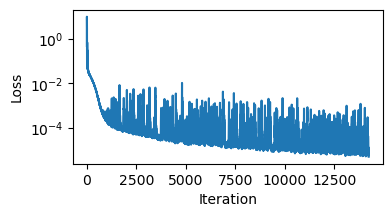

In [22]:
problem_config = {
    "f": f_harmonic,
    "f1": f1_harmonic,
    "f2": f2_harmonic,
    # "x_exact": x_exact_harmonic,
    "x_exact": lambda t, x0: x_fake_harmonic(t, x0, h=1., numerical_scheme="velocity_verlet"),
    "H": H_harmonic,
    "x0": np.array([1.0, 0.0], dtype=np.float32)
}

loss_config = {
    "numerical_scheme": "velocity_verlet",
    "h": 1.,
    "T": 4.,
    "ODE_colloc_mode": "random",
    "n_ODE": 2000,
    "IC_colloc_mode": "interval",
    "n_IC": 100,
    "strength_ODE": 1.0,
    "strength_IC": 1.0
}

optim_config = {
    "lr": 1e-3,
    "weight_decay": 0.1,
    "min_iterations": 10000,
    "iterations": 100000,
    "scheduler_params": {"step_size": 1000, "gamma": 1.0},
    # "scheduler_params": {"pct_start": 0.1}
    "threshold": 5e-6
}

torch.manual_seed(0)
model = Net(output_dim=2, x_0=problem_config["x0"], enforce_ic=True, n_neurons=500)
train(model, problem_config, loss_config, optim_config)

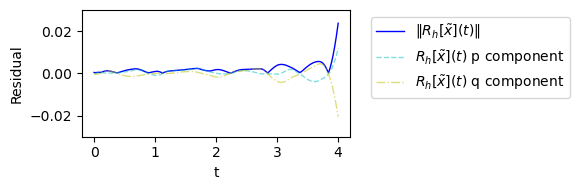

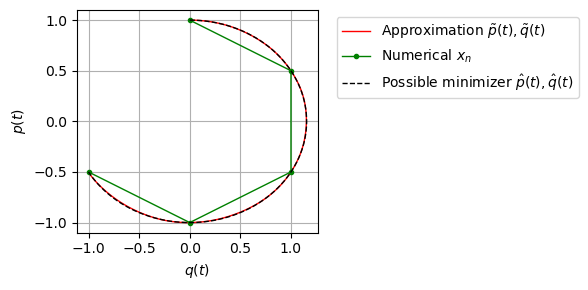

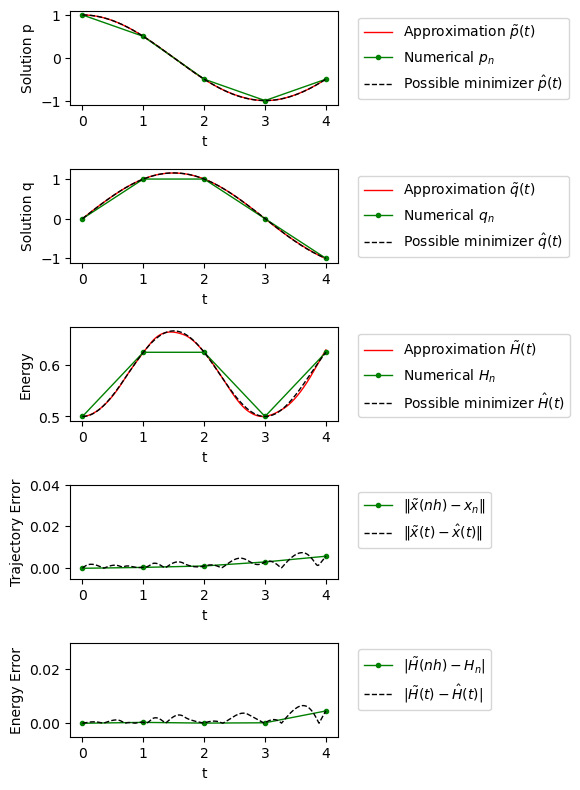

In [23]:
eval_config = {
    "n_eval": 10000,
    "t_range": [0, 4],
    "show_numerical": True,
    "numerical_scheme": "velocity_verlet",
    "h": 1.,
    "plot_error": True,
    "x_fake": lambda t, x0: x_fake_harmonic(t, x0, h=1., numerical_scheme="velocity_verlet"),
    "x_fake_label": "",
    "residual_ylim": [-3e-2, 3e-2],
    "traj_error_ylim": [-5e-3, 4e-2],
    "energy_error_ylim": [-5e-3, 3e-2]
}
test(model, problem_config, eval_config)

### Vary T

Training with implicit_trapezoidal
Using 1000 random collocation points on [0, 7.0] per iteration for ODE loss
Using 1 collocation point at 0 per iteration for IC loss
Iter 0: 	lr = 1.00e-03, loss = 1.820e+00, ODE loss = 1.820e+00, IC loss = 0.000e+00
Iter 500: 	lr = 1.00e-03, loss = 1.113e-02, ODE loss = 1.113e-02, IC loss = 0.000e+00
Iter 1000: 	lr = 1.00e-03, loss = 5.000e-03, ODE loss = 5.000e-03, IC loss = 0.000e+00
Iter 1500: 	lr = 1.00e-03, loss = 1.251e-03, ODE loss = 1.251e-03, IC loss = 0.000e+00
Iter 2000: 	lr = 1.00e-03, loss = 3.414e-04, ODE loss = 3.414e-04, IC loss = 0.000e+00
Iter 2500: 	lr = 1.00e-03, loss = 3.030e-04, ODE loss = 3.030e-04, IC loss = 0.000e+00
Iter 3000: 	lr = 1.00e-03, loss = 1.044e-04, ODE loss = 1.044e-04, IC loss = 0.000e+00
Iter 3500: 	lr = 1.00e-03, loss = 4.716e-04, ODE loss = 4.716e-04, IC loss = 0.000e+00
Iter 4000: 	lr = 1.00e-03, loss = 7.903e-05, ODE loss = 7.903e-05, IC loss = 0.000e+00
Iter 4500: 	lr = 1.00e-03, loss = 4.550e-04, ODE loss

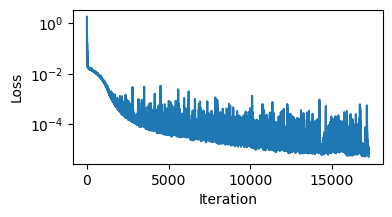

Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 5.960464477539063e-08
Converged after 1 iterations. Residual: 5.960464477539063e-08
Converged after 1 iterations. Residual: 8.429369557916289e-08
Converged after 1 iterations. Residual: 5.960464477539063e-08
Converged after 1 iterations. Residual: 5.960464477539063e-08
Converged after 1 iterations. Residual: 1.4901161193847656e-08
Converged after 1 iterations. Residual: 2.9802322387695312e-08
Converged after 1 iterations. Residual: 5.960464477539063e-08
Converged after 1 iterations. Residual: 8.429369557916289e-08
Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 5.960464477539063e-08
Converged after 1 iterations. Residual: 6.143906006172983e-08
Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 0.0
Converge

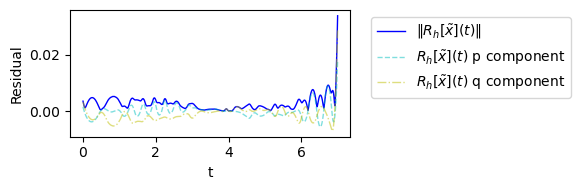

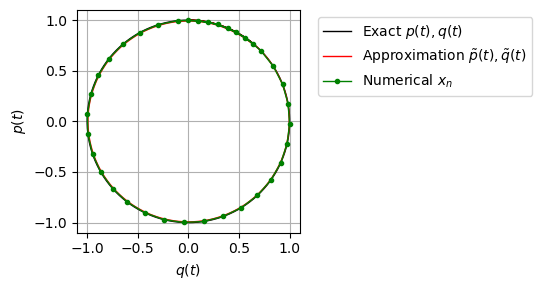

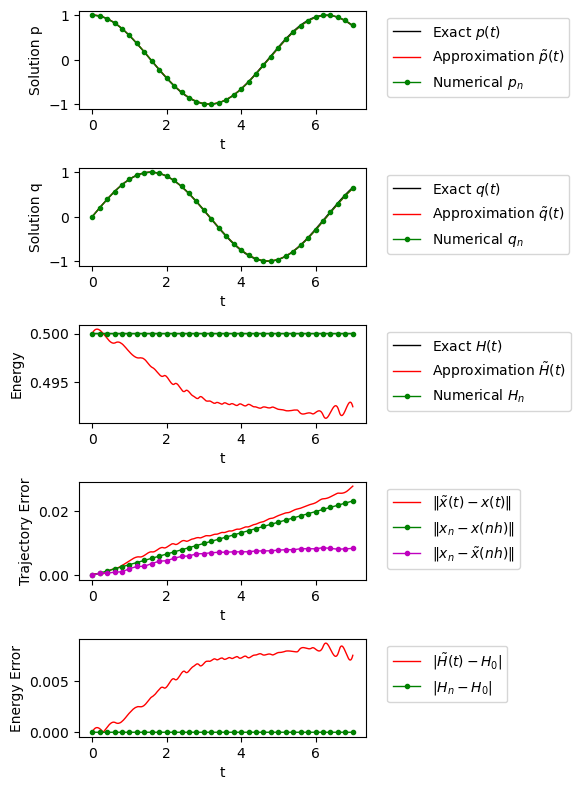

Training with implicit_trapezoidal
Using 1000 random collocation points on [0, 9.0] per iteration for ODE loss
Using 1 collocation point at 0 per iteration for IC loss
Iter 0: 	lr = 1.00e-03, loss = 2.323e+00, ODE loss = 2.323e+00, IC loss = 0.000e+00
Iter 500: 	lr = 1.00e-03, loss = 9.974e-03, ODE loss = 9.974e-03, IC loss = 0.000e+00
Iter 1000: 	lr = 1.00e-03, loss = 6.658e-03, ODE loss = 6.658e-03, IC loss = 0.000e+00
Iter 1500: 	lr = 1.00e-03, loss = 5.482e-03, ODE loss = 5.482e-03, IC loss = 0.000e+00
Iter 2000: 	lr = 1.00e-03, loss = 4.080e-03, ODE loss = 4.080e-03, IC loss = 0.000e+00
Iter 2500: 	lr = 1.00e-03, loss = 3.413e-03, ODE loss = 3.413e-03, IC loss = 0.000e+00
Iter 3000: 	lr = 1.00e-03, loss = 1.977e-03, ODE loss = 1.977e-03, IC loss = 0.000e+00
Iter 3500: 	lr = 1.00e-03, loss = 1.054e-03, ODE loss = 1.054e-03, IC loss = 0.000e+00
Iter 4000: 	lr = 1.00e-03, loss = 4.176e-04, ODE loss = 4.176e-04, IC loss = 0.000e+00
Iter 4500: 	lr = 1.00e-03, loss = 2.021e-04, ODE loss

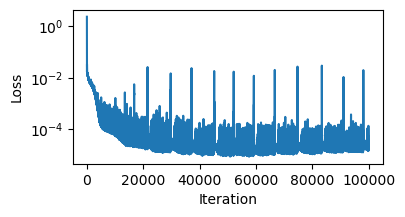

Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 5.960464477539063e-08
Converged after 1 iterations. Residual: 5.960464477539063e-08
Converged after 1 iterations. Residual: 8.429369557916289e-08
Converged after 1 iterations. Residual: 5.960464477539063e-08
Converged after 1 iterations. Residual: 5.960464477539063e-08
Converged after 1 iterations. Residual: 1.4901161193847656e-08
Converged after 1 iterations. Residual: 2.9802322387695312e-08
Converged after 1 iterations. Residual: 5.960464477539063e-08
Converged after 1 iterations. Residual: 8.429369557916289e-08
Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 5.960464477539063e-08
Converged after 1 iterations. Residual: 6.143906006172983e-08
Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 0.0
Converge

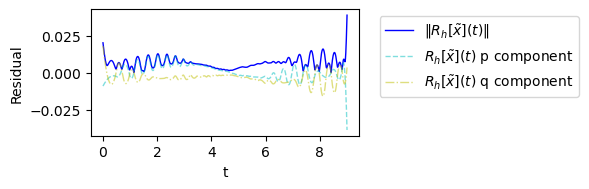

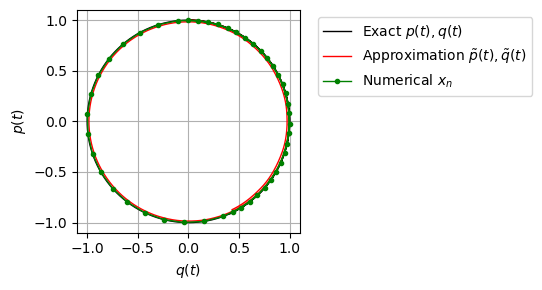

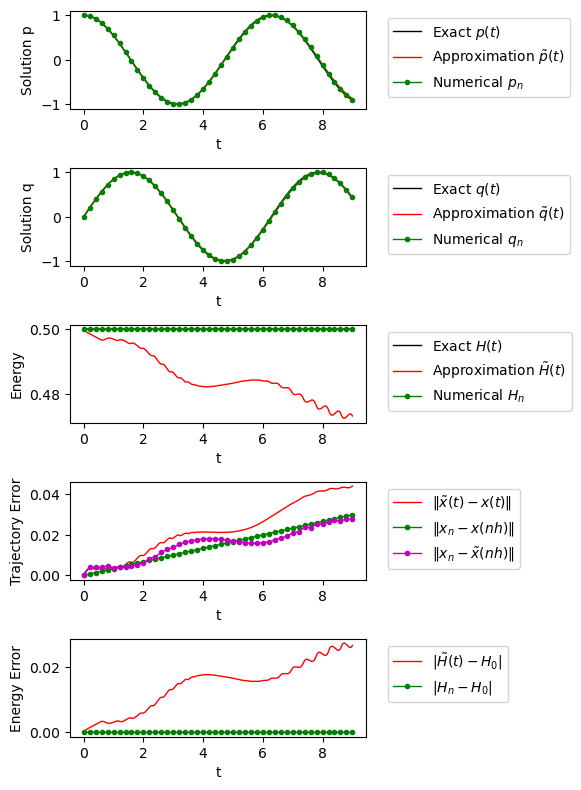

Training with implicit_trapezoidal
Using 1000 random collocation points on [0, 15.0] per iteration for ODE loss
Using 1 collocation point at 0 per iteration for IC loss
Iter 0: 	lr = 1.00e-03, loss = 4.439e+00, ODE loss = 4.439e+00, IC loss = 0.000e+00
Iter 500: 	lr = 1.00e-03, loss = 7.067e-03, ODE loss = 7.067e-03, IC loss = 0.000e+00
Iter 1000: 	lr = 1.00e-03, loss = 5.548e-03, ODE loss = 5.548e-03, IC loss = 0.000e+00
Iter 1500: 	lr = 1.00e-03, loss = 4.712e-03, ODE loss = 4.712e-03, IC loss = 0.000e+00
Iter 2000: 	lr = 1.00e-03, loss = 4.124e-03, ODE loss = 4.124e-03, IC loss = 0.000e+00
Iter 2500: 	lr = 1.00e-03, loss = 4.151e-03, ODE loss = 4.151e-03, IC loss = 0.000e+00
Iter 3000: 	lr = 1.00e-03, loss = 3.749e-03, ODE loss = 3.749e-03, IC loss = 0.000e+00
Iter 3500: 	lr = 1.00e-03, loss = 3.374e-03, ODE loss = 3.374e-03, IC loss = 0.000e+00
Iter 4000: 	lr = 1.00e-03, loss = 3.474e-03, ODE loss = 3.474e-03, IC loss = 0.000e+00
Iter 4500: 	lr = 1.00e-03, loss = 3.026e-03, ODE los

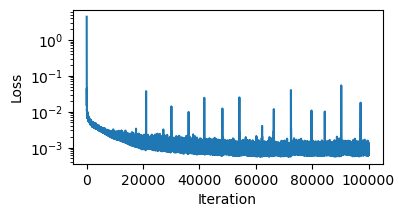

Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 5.960464477539063e-08
Converged after 1 iterations. Residual: 5.960464477539063e-08
Converged after 1 iterations. Residual: 8.429369557916289e-08
Converged after 1 iterations. Residual: 5.960464477539063e-08
Converged after 1 iterations. Residual: 5.960464477539063e-08
Converged after 1 iterations. Residual: 1.4901161193847656e-08
Converged after 1 iterations. Residual: 2.9802322387695312e-08
Converged after 1 iterations. Residual: 5.960464477539063e-08
Converged after 1 iterations. Residual: 8.429369557916289e-08
Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 5.960464477539063e-08
Converged after 1 iterations. Residual: 6.143906006172983e-08
Converged after 1 iterations. Residual: 0.0
Converged after 1 iterations. Residual: 0.0
Converge

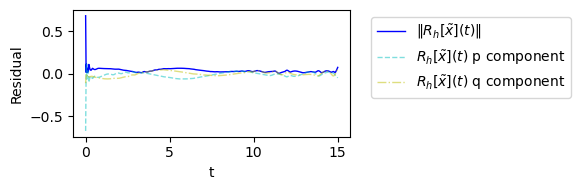

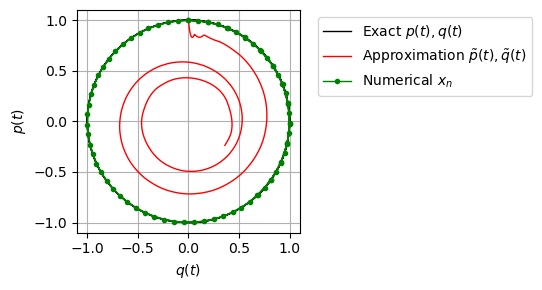

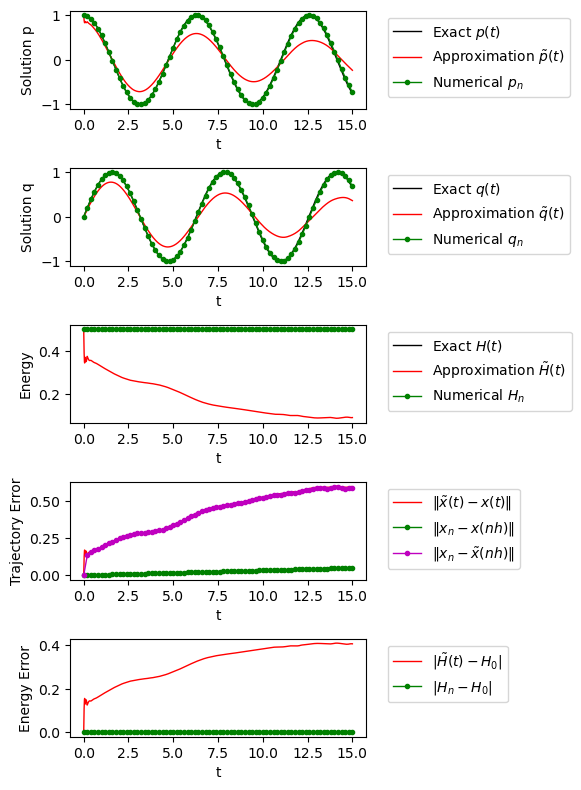

In [7]:
problem_config = {
    "f": f_harmonic,
    "x_exact": x_exact_harmonic,
    "H": H_harmonic,
    "x0": np.array([1.0, 0.0], dtype=np.float32)
}

loss_config = {
    "numerical_scheme": "implicit_trapezoidal",
    "h": 0.2,
    "T": 10.0,
    "ODE_colloc_mode": "random",
    "n_ODE": 1000,
    "IC_colloc_mode": "pointwise",
    "n_IC": 100,
    "strength_ODE": 1.0,
    "strength_IC": 0.0
}

optim_config = {
    "lr": 1e-3,
    "weight_decay": 0.1,
    "min_iterations": 10000,
    "iterations": 100000,
    "scheduler_params": {"step_size": 1000, "gamma": 1.0},
    "threshold": 5e-6
}

for T in [7., 9., 15.]:
    loss_config["T"] = T

    torch.manual_seed(0)
    model = Net(output_dim=2, x_0=problem_config["x0"], enforce_ic=True)
    train(model, problem_config, loss_config, optim_config)

    eval_config = {
        "n_eval": 10000,
        "t_range": [0, T],
        "show_numerical": True,
        "numerical_scheme": "implicit_trapezoidal",
        "h": 0.2,
        "plot_error": True
    }
    test(model, problem_config, eval_config)

## Pendulum 

$$H(p,q) = \frac{1}{2}p^2 - \cos(q) $$ 

$$\frac{d}{dt} \begin{bmatrix} p \\ q \end{bmatrix} = \begin{bmatrix} -\sin(q) \\ p \end{bmatrix}$$

$$p(0) = 0, q(0) = q_0$$ 
Solution: 

https://jgxsoft.com/examples/pendulum.html

https://en.wikipedia.org/wiki/Pendulum_(mechanics)#Arbitrary-amplitude_angular_displacement

In [15]:
# Define the ODE
def f_pendulum(x):
    p, q = torch.chunk(x, 2, dim=-1)
    return torch.cat([-torch.sin(q), p], dim=-1)

# Define the exact solution
def x_exact_pendulum(t, x0):
    """
    Compute the analytical solution [p(t), q(t)] of the pendulum problem given p(0) = 0 and q(0) = q0.
    """
    _, q0 = x0[..., 0:1], x0[..., 1:2]
    
    # Compute constants
    k = np.sin(q0 / 2)  # Elliptic modulus
    m = k ** 2          # Elliptic parameter

    # Compute elliptic functions
    sn, cn, dn, ph = ellipj(t, m)

    # Compute position and momentum
    q = 2 * np.arcsin(k * cn / dn)
    p = - 2 / np.cos(q/2) * k * (1-m) * sn / dn**2 

    return np.concatenate([p, q], axis=-1)

# Define the Hamiltonian
def H_pendulum(x):
    p, q = x[..., 0:1], x[..., 1:2]
    return 0.5 * p ** 2 - np.cos(q)

In [16]:
# Evaluate the trained model
def test(model, problem_config, eval_config):
    
    f = problem_config["f"]
    def x_exact(t):
        x_t = problem_config["x_exact"](t, problem_config["x0"])
        return x_t
    H = problem_config["H"]

    n_eval = eval_config["n_eval"]
    t_range = eval_config["t_range"]
    show_numerical = eval_config["show_numerical"]
    numerical_scheme = eval_config["numerical_scheme"]
    h = eval_config["h"]
    plot_error = eval_config["plot_error"]

    residual_fn = lambda model, t: {
        "forward_euler": residual_forward_euler,
        "backward_euler": residual_backward_euler,
        "implicit_trapezoidal": residual_implicit_trapezoidal,
        "implicit_midpoint": residual_implicit_midpoint}[numerical_scheme](model, t, h, f)
    numerical_step = lambda x_n, h: {
        "forward_euler": forward_euler_step,
        "backward_euler": backward_euler_step,
        "implicit_trapezoidal": implicit_trapezoidal_step,
        "implicit_midpoint": implicit_midpoint_step}[numerical_scheme](x_n, h, f)

    t_vals = torch.linspace(t_range[0], t_range[1], n_eval).reshape(-1, 1).to(device)
    residual_vals = residual_fn(model, t_vals).detach().cpu().numpy()
    x_vals = model(t_vals).detach().cpu().numpy()
    t_vals = t_vals.cpu().numpy()
    x_exact_vals = x_exact(t_vals)
    
    if show_numerical:
        x_numerical_vals = [problem_config["x0"]]
        t_numerical_vals = [np.array([0.], dtype=np.float32)]
        for _ in range(int(t_range[1] / h)):
            x_n = torch.tensor(x_numerical_vals[-1]).to(device)
            x_numerical_vals.append(numerical_step(x_n, h).detach().cpu().numpy())
            t_numerical_vals.append(t_numerical_vals[-1] + h)
        x_numerical_vals = np.array(x_numerical_vals)
        t_numerical_vals = np.array(t_numerical_vals)

    fig, ax = plt.subplots(1, 1, figsize=(6, 2))
    ax.plot(t_vals, np.linalg.norm(residual_vals, axis=-1), "-", lw=1, color="b", label=r"$\|R_h[\tilde{x}](t)\|$")
    ax.plot(t_vals, residual_vals[:, 0], "--", lw=1, color="c", alpha=0.5, label=r"$R_h[\tilde{x}](t)$ p component")
    ax.plot(t_vals, residual_vals[:, 1], "-.", lw=1, color="y", alpha=0.5, label=r"$R_h[\tilde{x}](t)$ q component")
    ax.set_xlabel("t")
    ax.set_ylabel("Residual")
    ax.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(7, 3))
    ax.plot(x_exact_vals[:, 1], x_exact_vals[:, 0], "-", lw=1, color="k", label=r"Exact $p(t), q(t)$")
    ax.plot(x_vals[:, 1], x_vals[:, 0], "-", lw=1, color="r", label=r"Approximation $\tilde{p}(t), \tilde{q}(t)$")
    if show_numerical:
        ax.plot(x_numerical_vals[:, 1], x_numerical_vals[:, 0], ".-", lw=1, color="g", label=r"Numerical $x_n$")
    ax.set_xlabel(r"$q(t)$")
    ax.set_ylabel(r"$p(t)$")
    ax.set_aspect("equal")
    ax.grid(True)
    ax.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(5, 1, figsize=(6, 8)) if plot_error else plt.subplots(3, 1, figsize=(6, 5))
    axes[0].plot(t_vals, x_exact_vals[:, 0], "-", lw=1, color="k", label=r"Exact $p(t)$")
    axes[0].plot(t_vals, x_vals[:, 0], "-", lw=1, color="r", label=r"Approximation $\tilde{p}(t)$")
    if show_numerical:
        axes[0].plot(t_numerical_vals, x_numerical_vals[:, 0], ".-", lw=1, color="g", label=r"Numerical $p_n$")
    axes[0].set_xlabel("t")
    axes[0].set_ylabel("Solution p")
    axes[0].legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")

    axes[1].plot(t_vals, x_exact_vals[:, 1], "-", lw=1, color="k", label=r"Exact $q(t)$")
    axes[1].plot(t_vals, x_vals[:, 1], "-", lw=1, color="r", label=r"Approximation $\tilde{q}(t)$")
    if show_numerical:
        axes[1].plot(t_numerical_vals, x_numerical_vals[:, 1], ".-", lw=1, color="g", label=r"Numerical $q_n$")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("Solution q")
    axes[1].legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")

    axes[2].plot(t_vals, H(x_exact_vals), "-", lw=1, color="k", label=r"Exact $H(t)$")
    axes[2].plot(t_vals, H(x_vals), "-", lw=1, color="r", label=r"Approximation $\tilde{H}(t)$")
    if show_numerical:
        axes[2].plot(t_numerical_vals, H(x_numerical_vals), ".-", lw=1, color="g", label=r"Numerical $H_n$")
    axes[2].set_xlabel("t")
    axes[2].set_ylabel("Energy")
    axes[2].legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")

    if plot_error:
        axes[3].plot(t_vals, np.linalg.norm(x_vals - x_exact_vals, axis=-1), "-", lw=1, color="r", label=r"$\| \tilde{x}(t) - x(t) \|$")
        if show_numerical:
            axes[3].plot(t_numerical_vals, np.linalg.norm(x_numerical_vals - x_exact(t_numerical_vals), axis=-1), ".-", lw=1, color="g", label=r"$\| x_n - x(nh) \|$")
            x_vals_at_t_numerical = model(torch.tensor(t_numerical_vals).to(device)).detach().cpu().numpy()
            axes[3].plot(t_numerical_vals, np.linalg.norm(x_numerical_vals - x_vals_at_t_numerical, axis=-1), ".-", lw=1, color="m", label=r"$\|x_n - \tilde{x}(nh)\|$")
        axes[3].set_xlabel("t")
        axes[3].set_ylabel("Trajectory Error")
        axes[3].legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")
        
        axes[4].plot(t_vals, np.abs(H(x_vals) - H(problem_config["x0"])), "-", lw=1, color="r", label=r"$|\tilde{H}(t) - H_0|$")
        if show_numerical:
            axes[4].plot(t_numerical_vals, np.abs(H(x_numerical_vals) - H(problem_config["x0"])), ".-", lw=1, color="g", label=r"$|H_n - H_0|$")
        axes[4].set_xlabel("t")
        axes[4].set_ylabel("Energy Error")
        axes[4].legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")

        # axes[3].plot(t_vals, x_vals[:, 0] - x_exact_vals[:, 0], "-", lw=1, color="r", label=r"$\tilde{p}(t) - p(t)$")
        # if show_numerical:
        #     axes[3].plot(t_numerical_vals, x_numerical_vals[:, 0] - x_exact(t_numerical_vals)[:, 0], ".-", lw=1, color="g", label=r"$p_n - p(nh)$")
        #     x_vals_at_t_numerical = model(torch.tensor(t_numerical_vals).to(device)).detach().cpu().numpy()
        #     axes[3].plot(t_numerical_vals, x_numerical_vals[:, 0] - x_vals_at_t_numerical[:, 0], ".-", lw=1, color="m", label=r"$p_n - \tilde{p}(nh)$")
        # axes[3].set_xlabel("t")
        # axes[3].set_ylabel("Error in p")
        # axes[3].legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")

        # axes[4].plot(t_vals, x_vals[:, 1] - x_exact_vals[:, 1], "-", lw=1, color="r", label=r"$\tilde{q}(t) - q(t)$")
        # if show_numerical:
        #     axes[4].plot(t_numerical_vals, x_numerical_vals[:, 1] - x_exact(t_numerical_vals)[:, 1], ".-", lw=1, color="g", label=r"$q_n - q(nh)$")
        #     x_vals_at_t_numerical = model(torch.tensor(t_numerical_vals).to(device)).detach().cpu().numpy()
        #     axes[4].plot(t_numerical_vals, x_numerical_vals[:, 1] - x_vals_at_t_numerical[:, 1], ".-", lw=1, color="m", label=r"$q_n - \tilde{q}(nh)$")
        # axes[4].set_xlabel("t")
        # axes[4].set_ylabel("Error in q")
        # axes[4].legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")

    plt.tight_layout()
    plt.show()

In [24]:
h_break = np.sqrt(-4/np.cos(np.pi * 3/4))
print(h_break)

2.378414230005442


Training with implicit_trapezoidal
Using 1000 random collocation points on [0, 3.0] per iteration for ODE loss
Using 1 collocation point at 0 per iteration for IC loss
Iter 0: 	lr = 1.00e-03, loss = 3.882e-01, ODE loss = 3.882e-01, IC loss = 0.000e+00
Iter 500: 	lr = 1.00e-03, loss = 6.560e-04, ODE loss = 6.560e-04, IC loss = 0.000e+00
Iter 1000: 	lr = 1.00e-03, loss = 5.273e-04, ODE loss = 5.273e-04, IC loss = 0.000e+00
Iter 1500: 	lr = 1.00e-03, loss = 4.818e-04, ODE loss = 4.818e-04, IC loss = 0.000e+00
Iter 2000: 	lr = 1.00e-03, loss = 4.483e-04, ODE loss = 4.483e-04, IC loss = 0.000e+00
Iter 2500: 	lr = 1.00e-03, loss = 3.917e-04, ODE loss = 3.917e-04, IC loss = 0.000e+00
Iter 3000: 	lr = 1.00e-03, loss = 4.353e-04, ODE loss = 4.353e-04, IC loss = 0.000e+00
Iter 3500: 	lr = 1.00e-03, loss = 2.935e-04, ODE loss = 2.935e-04, IC loss = 0.000e+00
Iter 4000: 	lr = 1.00e-03, loss = 2.820e-04, ODE loss = 2.820e-04, IC loss = 0.000e+00
Iter 4500: 	lr = 1.00e-03, loss = 2.696e-04, ODE loss

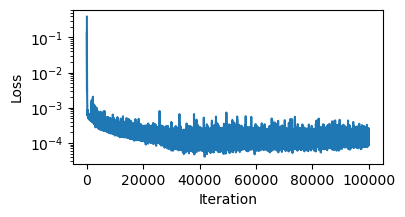

In [29]:
problem_config = {
    "f": f_pendulum,
    "x_exact": x_exact_pendulum,
    "H": H_pendulum,
    "x0": np.array([0.0, np.pi * 3/4], dtype=np.float32)
}

loss_config = {
    "numerical_scheme": "implicit_trapezoidal",
    "h": h_break+0.1,
    "T": 3.0,
    "ODE_colloc_mode": "random",
    "n_ODE": 1000,
    "IC_colloc_mode": "pointwise",
    "n_IC": 100,
    "strength_ODE": 1.0,
    "strength_IC": 0.0
}

optim_config = {
    "lr": 1e-3,
    "weight_decay": 0.1,
    "min_iterations": 5000,
    "iterations": 100000,
    "scheduler_params": {"step_size": 1000, "gamma": 1.0},
    # "scheduler_params": {"pct_start": 0.1}
    "threshold": 1e-5
}

torch.manual_seed(0)
model = Net(output_dim=2, x_0=problem_config["x0"], enforce_ic=True)
train(model, problem_config, loss_config, optim_config)

Converged after 80 iterations. Residual: 0.0


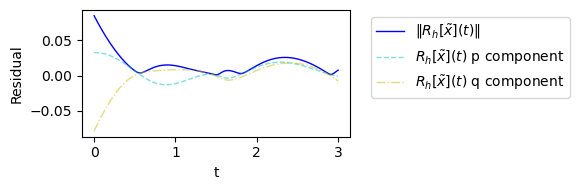

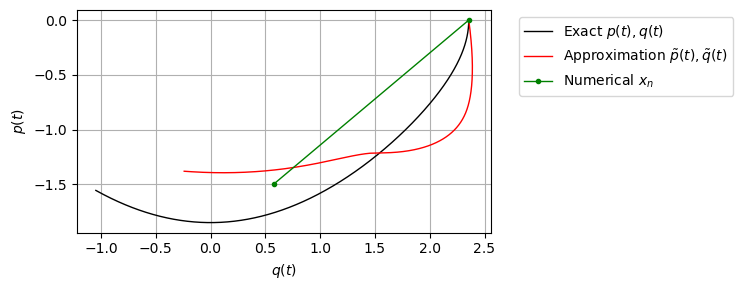

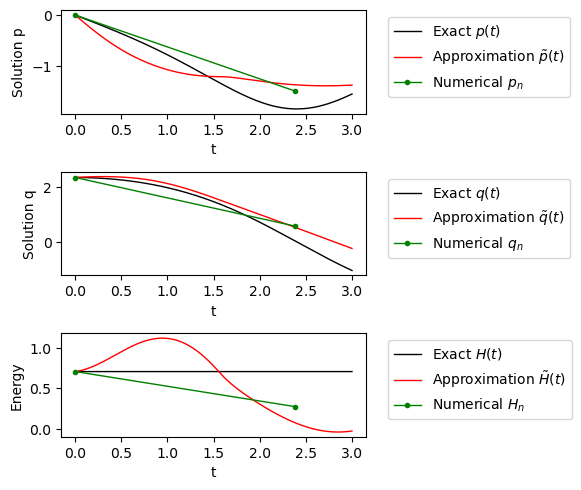

In [28]:
eval_config = {
    "n_eval": 10000,
    "t_range": [0, 3],
    "show_numerical": True,
    "numerical_scheme": "implicit_trapezoidal",
    "h": h_break,
    "plot_error": False
}
test(model, problem_config, eval_config)

In [23]:
h_break = np.sqrt(-4/np.cos(np.pi * 3/4))
print(h_break)

2.378414230005442


## 3-Body 

$$H(p,q) = \frac{1}{2}\left( \frac{p_1^2}{m_1} + \frac{p_2^2}{m_2} + \frac{p_3^2}{m_3}\right) - \frac{G m_1 m_2}{\| q_1 - q_2 \|} - \frac{G m_1 m_3}{\| q_1 - q_3 \|} - \frac{G m_2 m_3}{\| q_2 - q_3 \|} $$ 

$$\frac{d q_i}{dt} = \frac{p_i}{m_i}, \quad i=1,2,3 $$

$$\frac{d p_1}{dt} = - G m_1 \left(m_2 \frac{q_1 - q_2}{\| q_1 - q_2 \|^3} + m_3 \frac{q_1 - q_3}{\| q_1 - q_3 \|^3}\right) $$
$$\frac{d p_2}{dt} = - G m_2 \left(m_1 \frac{q_2 - q_1}{\| q_1 - q_2 \|^3} + m_3 \frac{q_2 - q_3}{\| q_2 - q_3 \|^3}\right) $$
$$\frac{d p_3}{dt} = - G m_3 \left(m_1 \frac{q_3 - q_1}{\| q_1 - q_3 \|^3} + m_2 \frac{q_3 - q_2}{\| q_2 - q_3 \|^3}\right) $$

Parameters: $G=1, m_1=100, m_2=1, m_3=0.001$

Initial condition: 
$$
\begin{align*} 
    p_1(0) &= [0,     -1.0001,     -0.0001   ] \\
    p_2(0) &= [0,     1,     0  ] \\
    p_3(0) &= [0,     0.0001,    0.0001   ] \\
    q_1(0) &= [-1.00102,     0,     0   ] \\
    q_2(0) &= [100,     0,    0  ] \\
    q_3(0) &= [102,     0,    0   ]
\end{align*} 
$$



In [6]:
from dataprocessing_utils.threebody import ThreeBody, ThreeBodyDataset, ThreeBodyTrajectory, REF_TRAJ_DT, REF_TRAJ_FILEPATHS

Trajectory = ThreeBodyTrajectory
Dataset = ThreeBodyDataset

In [7]:
def plot_phase_space_3d(dataset_or_trajs, axis_lims=None, linestyles=None, legend_labels=None, axis_labels=None, 
                     titles=None, figsize=(12, 4), show_legend=False, save_path=None):
    
    if axis_lims is None:
        # axis_lims = [[(-5., 5.), (-5., 5.), (-5., 5.)]] * 3  # Default axis limits for all subplots
        axis_lims = [[None, None, None]] * 3  # Default axis limits for all subplots

    if linestyles is None:
        linestyles = ['-'] * len(dataset_or_trajs)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(dataset_or_trajs))]  # Default labels for legends

    if axis_labels is None:
        axis_labels = [('$q_{1x}$', '$q_{1y}$', '$q_{1z}$'), 
                       ('$q_{2x}$', '$q_{2y}$', '$q_{2z}$'),
                       ('$q_{3x}$', '$q_{3y}$', '$q_{3z}$')]  # Default axis labels

    if titles is None:
        titles = ['Body 1', 'Body 2', 'Body 3']  # Default titles for subplots

    fig = plt.figure(figsize=figsize, layout='constrained')
    axes = fig.subplots(1, 3, subplot_kw={'projection': '3d'})  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, linestyle, legend_label in zip(dataset_or_trajs, linestyles, legend_labels):
        _, (q1, q2, q3) = traj.states.get_pq()
        if legend_label == 'ref' or legend_label == 'Reference':
            line1, = axes[0].plot(q1[:, 0], q1[:, 1], q1[:, 2], linestyle, lw=1, color='k', alpha=0.3, label=legend_label)
            axes[1].plot(q2[:, 0], q2[:, 1], q2[:, 2], linestyle, lw=1, color='k', alpha=0.3)
            axes[2].plot(q3[:, 0], q3[:, 1], q3[:, 2], linestyle, lw=1, color='k', alpha=0.3)
        elif legend_label == 'Numerical':
            line1, = axes[0].plot(q1[:, 0], q1[:, 1], q1[:, 2], '.-', lw=1, color='g', label=legend_label)
            axes[1].plot(q2[:, 0], q2[:, 1], q2[:, 2], '.-', lw=1, color='g')
            axes[2].plot(q3[:, 0], q3[:, 1], q3[:, 2], '.-', lw=1, color='g')
        else:
            line1, = axes[0].plot(q1[:, 0], q1[:, 1], q1[:, 2], linestyle, lw=1, label=legend_label)
            axes[1].plot(q2[:, 0], q2[:, 1], q2[:, 2], linestyle, lw=1)
            axes[2].plot(q3[:, 0], q3[:, 1], q3[:, 2], linestyle, lw=1)
        lines.append(line1)  # Append the line object for the legend
        

    # Set labels and titles for each subplot
    for i, ax in enumerate(axes):
        if axis_lims is not None:
            ax.set_xlim(axis_lims[i][0])
            ax.set_ylim(axis_lims[i][1])
            ax.set_zlim(axis_lims[i][2])
        ax.set_xlabel(axis_labels[i][0])
        ax.set_ylabel(axis_labels[i][1])
        ax.set_zlabel(axis_labels[i][2])
        ax.set_title(titles[i])

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return

def plot_phase_space_3d_together(dataset_or_traj, axis_lims=None, linestyles=None, legend_labels=None, axis_labels=None, 
                     title=None, figsize=(6, 4), show_legend=False, save_path=None):
    
    if axis_lims is None:
        axis_lims = [None, None, None]  # Default axis limits 

    if linestyles is None:
        linestyles = ['-'] * 3  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Body 1', 'Body 2', 'Body 3']

    if axis_labels is None:
        axis_labels = ['x', 'y', 'z']  # Default axis labels

    fig = plt.figure(figsize=figsize, layout='constrained')
    ax = fig.subplots(1, 1, subplot_kw={'projection': '3d'})  # Use plt.subplots to manage multiple axes

    _, (q1, q2, q3) = dataset_or_traj.states.get_pq()
    ax.plot(q1[:, 0], q1[:, 1], q1[:, 2], linestyles[0], lw=1, label=legend_labels[0])
    ax.plot(q2[:, 0], q2[:, 1], q2[:, 2], linestyles[1], lw=1, label=legend_labels[1])
    ax.plot(q3[:, 0], q3[:, 1], q3[:, 2], linestyles[2], lw=1, label=legend_labels[2])

    # Set labels and titles for each subplot
    ax.set_xlim(axis_lims[0])
    ax.set_ylim(axis_lims[1])
    ax.set_zlim(axis_lims[2])
    ax.set_xlabel(axis_labels[0])
    ax.set_ylabel(axis_labels[1])
    ax.set_zlabel(axis_labels[2])
    ax.set_title(title)

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return

def plot_history(dataset_or_trajs, func_dict, linestyles=None, alpha=1., legend_labels=None, xlabel="t", ylabels=None, ylims=None, 
               figsize=None, show_legend=True, save_path=None):
    
    if linestyles is None:
        linestyles = ['-'] * len(dataset_or_trajs)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(dataset_or_trajs))]  # Default labels for legends
    
    if ylabels is None:
        ylabels = list(func_dict.keys())  # Default y axis labels

    if ylims is None:
        ylims = [(None, None)] * len(func_dict.keys())
    
    if figsize is None:
        figsize = (8, 1.5 * len(func_dict))

    fig, axes = plt.subplots(len(func_dict), 1, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, linestyle, legend_label in zip(dataset_or_trajs, linestyles, legend_labels):
        xdata = traj.times if isinstance(traj, Trajectory) else np.arange(len(traj))
        for i, (key, func) in enumerate(func_dict.items()):
            if len(func_dict) > 1:
                if legend_label == 'ref' or legend_label == 'Reference':
                    line1, = axes[i].plot(xdata, func(traj.states.u), linestyle, lw=1, alpha=0.2, color='k', label=legend_label)
                elif legend_label == 'Numerical':
                    line1, = axes[i].plot(xdata, func(traj.states.u), '.-', lw=1, color='g', label=legend_label)
                else:
                    line1, = axes[i].plot(xdata, func(traj.states.u), linestyle, lw=1, alpha=alpha, label=legend_label)
            else:
                if legend_label == 'ref' or legend_label == 'Reference':
                    line1, = axes.plot(xdata, func(traj.states.u), linestyle, lw=1, alpha=0.2, color='k', label=legend_label)
                elif legend_label == 'Numerical':
                    line1, = axes.plot(xdata, func(traj.states.u), '.-', lw=1, color='g', label=legend_label)
                else:
                    line1, = axes.plot(xdata, func(traj.states.u), linestyle, lw=1, alpha=alpha, label=legend_label)
        lines.append(line1) # Append the line object for the legend

    # Set labels and titles for each subplot
    if len(func_dict) > 1:
        for i, ax in enumerate(axes):
            ax.set_ylim(ylims[i])
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabels[i])
    else:
        axes.set_ylim(ylims[0])
        axes.set_xlabel(xlabel)
        axes.set_ylabel(ylabels[0])

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return 

def plot_errors(trajs, ref_trajs, linestyles=None, legend_labels=None, titles=None, error_names=None, 
                ylims=None, ylabels=None, figsize=(7, 4), log_yscale=True, show_legend=False, save_path=None):
    
    if isinstance(ref_trajs, Trajectory):
        ref_trajs = [ref_trajs] * len(trajs)
    elif isinstance(ref_trajs, list):
        assert len(trajs) == len(ref_trajs), "Number of trajs and ref_trajs must be the same"
    else:
        raise ValueError("ref_trajs must be a Trajectory or a list of Trajectories")

    if linestyles is None:
        linestyles = ['-'] * len(trajs)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(trajs))]  # Default labels for legends
    
    if error_names is None:
        error_names = ["abs_traj_err", "abs_H_err"]
    
    if ylims is None:
        ylims = [(1e-4, 1e0)] * len(error_names)  # Default ylims for subplots
    
    if ylabels is None:
        ylabels = error_names  # Default y axis labels

    fig, axes = plt.subplots(len(error_names), 1, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for traj, ref_traj, linestyle, legend_label in zip(trajs, ref_trajs, linestyles, legend_labels):
        tt, errors = traj.compare(ref_traj)
        for i, error_name in enumerate(error_names):
            if len(error_names) > 1:
                line1, = axes[i].plot(tt, errors[error_name], linestyle, lw=1, label=legend_label)
            else:
                line1, = axes.plot(tt, errors[error_name], linestyle, lw=1, label=legend_label)
            lines.append(line1)
        # line1, = axes[0].plot(tt, errors[error_names[0]], linestyle, lw=1, label=legend_label)
        # axes[1].plot(tt, errors[error_names[1]], linestyle, lw=1)
        # lines.append(line1)  # Append the line object for the legend

    # Set labels and titles for each subplot
    for i, ax in enumerate(axes.flatten()):
        ax.set_ylim(ylims[i])
        ax.set_xlabel('$t$')
        ax.set_ylabel(ylabels[i])
        if log_yscale:
            ax.set_yscale('log')

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

    return


ThreeBodyTrajectory(t_range=[0.0, 1000.0], dt=0.01, u0=[ 0.00000e+00 -1.00010e-02 -1.00000e-06  0.00000e+00  1.00000e+00
  0.00000e+00  0.00000e+00  1.00000e-01  1.00000e-01 -1.00102e+00
  0.00000e+00  0.00000e+00  1.00000e+02  0.00000e+00  0.00000e+00
  1.02000e+02  0.00000e+00  0.00000e+00], states=States(problem=ThreeBody(m1=100.0, m2=1.0, m3=0.001, G=1.0), shape=(100001, 18)))


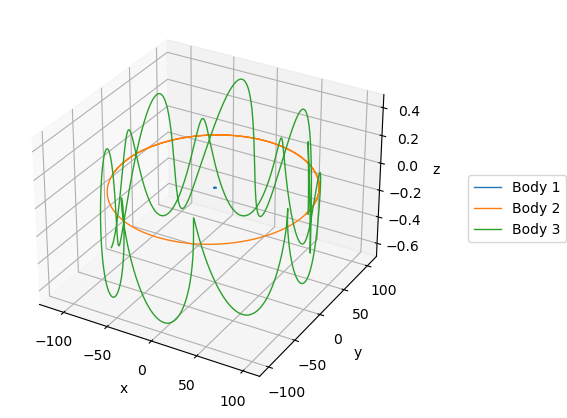

In [8]:
# Sun-Earth-Moon system
ref_traj = Trajectory.load_from_file(REF_TRAJ_FILEPATHS[2], dt=REF_TRAJ_DT, m1=100., m2=1., m3=0.001)

threebody = ThreeBody(m1=100., m2=1., m3=0.001)
func_dict = {
    "H": threebody.compute_hamiltonian,
    "K": threebody.compute_kinetic_energy,
    "U": threebody.compute_potential_energy,
    "r12": threebody.compute_r12,
    "r13": threebody.compute_r13,
    "r23": threebody.compute_r23,
    "Lx": lambda u: threebody.compute_total_angular_momentum(u)[:, 0],
    "Ly": lambda u: threebody.compute_total_angular_momentum(u)[:, 1],
    "Lz": lambda u: threebody.compute_total_angular_momentum(u)[:, 2],
    "Px": lambda u: threebody.compute_total_momentum(u)[:, 0],
    "Py": lambda u: threebody.compute_total_momentum(u)[:, 1],       
    "Pz": lambda u: threebody.compute_total_momentum(u)[:, 2],
}

traj = ref_traj.select_between(0, 1000)
print(traj)
# plot_phase_space_3d([traj])
plot_phase_space_3d_together(traj, show_legend=True)
# plot_history([traj], func_dict, xlabel="t")

In [9]:
ref_traj.select_between(0, 1).states.convert_vx_to_pq()

array([[ 0.00000000e+00, -1.00010000e+00, -1.00000000e-04, ...,
         1.02000000e+02,  0.00000000e+00,  0.00000000e+00],
       [ 9.81218825e-05, -1.00010000e+00, -9.99999995e-05, ...,
         1.01999987e+02,  1.00001875e-03,  9.99997915e-04],
       [ 1.96243764e-04, -1.00009998e+00, -9.99999982e-05, ...,
         1.01999948e+02,  2.00014998e-03,  1.99998332e-03],
       ...,
       [ 9.61578453e-03, -1.00005292e+00, -9.99955487e-05, ...,
         1.01878772e+02,  1.14965481e-01,  9.61133333e-02],
       [ 9.71390147e-03, -1.00005196e+00, -9.99954572e-05, ...,
         1.01876352e+02,  1.16476506e-01,  9.70565028e-02],
       [ 9.81201830e-03, -1.00005098e+00, -9.99953647e-05, ...,
         1.01873910e+02,  1.17997290e-01,  9.79985870e-02]])

ThreeBodyTrajectory(t_range=[0.0, 200.0], dt=0.01, u0=[ 0.00000e+00 -1.00010e-02 -1.00000e-06  0.00000e+00  1.00000e+00
  0.00000e+00  0.00000e+00  1.00000e-01  1.00000e-01 -1.00102e+00
  0.00000e+00  0.00000e+00  1.00000e+02  0.00000e+00  0.00000e+00
  1.02000e+02  0.00000e+00  0.00000e+00], states=States(problem=ThreeBody(m1=100.0, m2=1.0, m3=0.001, G=1.0), shape=(20001, 18))) ThreeBodyTrajectory(t_range=[0.1, 200.1], dt=0.009999999999999995, u0=[ 9.81218657e-06 -1.00009951e-02 -9.99999538e-07 -9.55291274e-04
  9.99998948e-01  6.24554929e-08 -2.59273829e-02  1.00562053e-01
  9.99374983e-02 -1.00101951e+00 -1.00009984e-03 -9.99999846e-08
  9.99999522e+01  9.99999649e-02  2.08243652e-09  1.01998703e+02
  1.00187404e-02  9.99791602e-03], states=States(problem=ThreeBody(m1=100.0, m2=1.0, m3=0.001, G=1.0), shape=(20001, 18)))
[[-8.49986659e-10  3.10862447e-13  5.79085933e-15 ... -3.79953917e-06
  -1.87403965e-04  2.08397793e-05]
 [-8.49986216e-10  1.08801856e-13  8.09058766e-15 ... -5.318

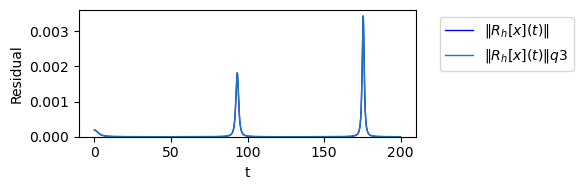

In [74]:
# Local truncation error 

T = 200
h = 0.1
traj = ref_traj.select_between(0, T)
traj2 = ref_traj.select_between(h, T+h)
print(traj, traj2)

t_vals = traj.times
x_n = torch.tensor(traj.states.convert_vx_to_pq())
x_np = torch.tensor(traj2.states.convert_vx_to_pq())
residual_vals = 1/h * (velocity_verlet_step(x_n, h, f1_3body, f2_3body) - x_np).numpy()
print(residual_vals)

fig, ax = plt.subplots(1, 1, figsize=(6, 2))
ax.plot(t_vals, np.linalg.norm(residual_vals, axis=-1), "-", lw=1, color="b", label=r"$\|R_h[x](t)\|$")
# ax.plot(t_vals, np.linalg.norm(residual_vals[:, :9], axis=-1), "-", lw=1, color="c", label=r"$\|R_h[x](t)\| p$")
# ax.plot(t_vals, np.linalg.norm(residual_vals[:, 9:], axis=-1), "-", lw=1, color="y", label=r"$\|R_h[x](t)\| q$")
# ax.plot(t_vals, np.linalg.norm(residual_vals[:, :3], axis=-1), "-", lw=1, label=r"$\|R_h[x](t)\| p1$")
# ax.plot(t_vals, np.linalg.norm(residual_vals[:, 3:6], axis=-1), "-", lw=1, label=r"$\|R_h[x](t)\| p2$")
# ax.plot(t_vals, np.linalg.norm(residual_vals[:, 6:9], axis=-1), "-", lw=1, label=r"$\|R_h[x](t)\| p3$")
# ax.plot(t_vals, np.linalg.norm(residual_vals[:, 9:12], axis=-1), "-", lw=1, label=r"$\|R_h[x](t)\| q1$")
# ax.plot(t_vals, np.linalg.norm(residual_vals[:, 12:15], axis=-1), "-", lw=1, label=r"$\|R_h[x](t)\| q2$")
ax.plot(t_vals, np.linalg.norm(residual_vals[:, 15:18], axis=-1), "-", lw=1, label=r"$\|R_h[x](t)\| q3$")
ax.set_ylim(0, None)
ax.set_xlabel("t")
ax.set_ylabel("Residual")
ax.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")
plt.tight_layout()
plt.show()

In [10]:
M1, M2, M3 = 100.0, 1.0, 0.001

# Define the ODE
def f_3body(x):
    p, q = torch.chunk(x, 2, dim=-1)
    p1, p2, p3 = torch.chunk(p, 3, dim=-1)
    q1, q2, q3 = torch.chunk(q, 3, dim=-1)
    r12 = torch.norm(q1 - q2, dim=-1, keepdim=True)
    r13 = torch.norm(q1 - q3, dim=-1, keepdim=True)
    r23 = torch.norm(q2 - q3, dim=-1, keepdim=True)
    dp1 = - M1 * (M2 * (q1-q2) / r12**3 + M3 * (q1-q3) / r13**3)
    dp2 = - M2 * (M1 * (q2-q1) / r12**3 + M3 * (q2-q3) / r23**3)
    dp3 = - M3 * (M1 * (q3-q1) / r13**3 + M2 * (q3-q2) / r23**3)
    dq1 = p1 / M1
    dq2 = p2 / M2
    dq3 = p3 / M3
    return torch.cat([dp1, dp2, dp3, dq1, dq2, dq3], dim=-1)

def f1_3body(q):
    q1, q2, q3 = torch.chunk(q, 3, dim=-1)
    r12 = torch.norm(q1 - q2, dim=-1, keepdim=True)
    r13 = torch.norm(q1 - q3, dim=-1, keepdim=True)
    r23 = torch.norm(q2 - q3, dim=-1, keepdim=True)
    dp1 = - M1 * (M2 * (q1-q2) / r12**3 + M3 * (q1-q3) / r13**3)
    dp2 = - M2 * (M1 * (q2-q1) / r12**3 + M3 * (q2-q3) / r23**3)
    dp3 = - M3 * (M1 * (q3-q1) / r13**3 + M2 * (q3-q2) / r23**3)
    return torch.cat([dp1, dp2, dp3], dim=-1)

def f2_3body(p):
    p1, p2, p3 = torch.chunk(p, 3, dim=-1)
    return torch.cat([p1 / M1, p2 / M2, p3 / M3], dim=-1)

# Define the Hamiltonian
def H_3body(x):
    p, q = torch.chunk(x, 2, dim=-1)
    p1, p2, p3 = torch.chunk(p, 3, dim=-1)
    q1, q2, q3 = torch.chunk(q, 3, dim=-1)
    K = 0.5 * (torch.sum(p1 ** 2, dim=-1) / M1 + torch.sum(p2 ** 2, dim=-1) / M2 + torch.sum(p3 ** 2, dim=-1) / M3)
    U = - M1 * M2 / torch.norm(q1 - q2, dim=-1) - M1 * M3 / torch.norm(q1 - q3, dim=-1) - M2 * M3 / torch.norm(q2 - q3, dim=-1)
    return K + U

def ic_3body():
    p1 = [0, -1.0001, -0.0001]
    p2 = [0, 1, 0]
    p3 = [0, 0.0001, 0.0001]
    q1 = [-1.00102, 0, 0]
    q2 = [100, 0, 0]
    q3 = [102, 0, 0]
    return np.array([p1, p2, p3, q1, q2, q3], dtype=np.float32).flatten()

def x_fake_3body(t, x0, x1, h=0.1):
    # Interpolate between x0 and x1
    return x0 + t/h * (x1 - x0)

In [11]:
x0 = torch.tensor(ic_3body())
x1 = velocity_verlet_step(torch.tensor(ic_3body()), 0.1, f1_3body, f2_3body)

torch.allclose(x_fake_3body(0.1, x0, x1, h=0.1), x1)

True

In [25]:
def energy_balanced_loss(x_pred, x_true):
    def energy_balanced_transform(x):
        p, q = torch.chunk(x, 2, dim=-1)
        p1, p2, p3 = torch.chunk(p, 3, dim=-1)
        q1, q2, q3 = torch.chunk(q, 3, dim=-1)
        r12 = torch.norm(q1 - q2, dim=-1, keepdim=True)
        r13 = torch.norm(q1 - q3, dim=-1, keepdim=True)
        r23 = torch.norm(q2 - q3, dim=-1, keepdim=True)
        return torch.cat([p1 / (2*M1)**0.5, p2 / (2*M2)**0.5, p3 / (2*M3)**0.5, 
                          torch.sqrt(M1*M2/r12), torch.sqrt(M1*M3/r13), torch.sqrt(M2*M3/r23),
                          q1, q2, q3], dim=-1)
    return nn.functional.mse_loss(energy_balanced_transform(x_pred), energy_balanced_transform(x_true))

In [28]:
x0 = torch.tensor(ic_3body())
x1 = velocity_verlet_step(torch.tensor(ic_3body()), 1., f1_3body, f2_3body)

print(energy_balanced_loss(x0, x1))
print(nn.functional.mse_loss(x0, x1))

tensor(0.0494)
tensor(0.0576)


In [15]:
# Evaluate the trained model
def test(model, problem_config, eval_config):
    
    f = problem_config["f"]
    f1 = problem_config["f1"]
    f2 = problem_config["f2"]
    def x_exact(t):
        x_t = problem_config["x_exact"](t, problem_config["x0"])
        return x_t
    H = problem_config["H"]

    n_eval = eval_config["n_eval"]
    t_range = eval_config["t_range"]
    show_numerical = eval_config["show_numerical"]
    numerical_scheme = eval_config["numerical_scheme"]
    h = eval_config["h"]
    plot_error = eval_config["plot_error"]
    residual_ylim = eval_config["residual_ylim"]
    traj_error_ylim = eval_config["traj_error_ylim"]
    energy_error_ylim = eval_config["energy_error_ylim"]
    
    if numerical_scheme == "velocity_verlet":
        residual_fn = lambda model, t: residual_velocity_verlet(model, t, h, f1, f2)
        numerical_step = lambda x_n, h: velocity_verlet_step(x_n, h, f1, f2)
    else:
        residual_fn = lambda model, t: {
            "forward_euler": residual_forward_euler,
            "backward_euler": residual_backward_euler,
            "implicit_trapezoidal": residual_implicit_trapezoidal,
            "implicit_midpoint": residual_implicit_midpoint}[numerical_scheme](model, t, h, f)
        numerical_step = lambda x_n, h: {
            "forward_euler": forward_euler_step,
            "backward_euler": backward_euler_step,
            "implicit_trapezoidal": implicit_trapezoidal_step,
            "implicit_midpoint": implicit_midpoint_step}[numerical_scheme](x_n, h, f)

    # t_vals = torch.linspace(t_range[0], t_range[1], n_eval).reshape(-1, 1).to(device)
    t_vals = torch.arange(0, n_eval+1) * (t_range[1] - t_range[0]) / n_eval + t_range[0]
    t_vals = t_vals.reshape(-1, 1).to(device)
    residual_vals = residual_fn(model, t_vals)[0].detach().cpu().numpy()
    x_vals = model(t_vals).detach().cpu().numpy()
    t_vals = t_vals.cpu().numpy()
    # x_exact_vals = x_exact(t_vals)
    # x_fake_vals = x_fake(t_vals)

    if show_numerical:
        x_numerical_vals = [problem_config["x0"]]
        # x_numerical_vals = [model(torch.tensor([2*h]).to(device)).detach().cpu().numpy()]
        t_numerical_vals = [np.array([0.], dtype=np.float32)]
        # t_numerical_vals = [np.array([2*h], dtype=np.float32)]
        for _ in range(int(t_range[1] / h)):
            x_n = torch.tensor(x_numerical_vals[-1]).to(device)
            x_numerical_vals.append(numerical_step(x_n, h).detach().cpu().numpy())
            t_numerical_vals.append(t_numerical_vals[-1] + h)
        x_numerical_vals = np.array(x_numerical_vals)
        t_numerical_vals = np.array(t_numerical_vals)

    fig, ax = plt.subplots(1, 1, figsize=(6, 2))
    ax.plot(t_vals, np.linalg.norm(residual_vals, axis=-1), "-", lw=1, color="b", label=r"$\|R_h[\tilde{x}](t)\|$")
    ax.plot(t_vals, np.linalg.norm(residual_vals[:, :9], axis=-1), "-", lw=1, color="c", label=r"$\|R_h[\tilde{x}](t)\| p$")
    ax.plot(t_vals, np.linalg.norm(residual_vals[:, 9:], axis=-1), "-", lw=1, color="y", label=r"$\|R_h[\tilde{x}](t)\| q$")
    ax.plot(t_vals, np.linalg.norm(residual_vals[:, :3], axis=-1), "-", lw=1, label=r"$\|R_h[\tilde{x}](t)\| p1$")
    ax.plot(t_vals, np.linalg.norm(residual_vals[:, 3:6], axis=-1), "-", lw=1, label=r"$\|R_h[\tilde{x}](t)\| p2$")
    ax.plot(t_vals, np.linalg.norm(residual_vals[:, 6:9], axis=-1), "-", lw=1, label=r"$\|R_h[\tilde{x}](t)\| p3$")
    ax.set_ylim(residual_ylim)
    ax.set_xlabel("t")
    ax.set_ylabel("Residual")
    ax.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")
    plt.tight_layout()
    plt.show()

    ref_traj = Trajectory.load_from_file(REF_TRAJ_FILEPATHS[2], dt=REF_TRAJ_DT, m1=100., m2=1., m3=0.001)
    ref_traj = ref_traj.select_between(t_range[0], t_range[1])

    traj = Trajectory.from_pq(t_vals.flatten(), x_vals)
    if show_numerical:
        numerical_traj = Trajectory.from_pq(t_numerical_vals.flatten(), x_numerical_vals)

    threebody = ThreeBody(m1=100., m2=1., m3=0.001)
    func_dict = {
        "H": threebody.compute_hamiltonian,
        "K": threebody.compute_kinetic_energy,
        "U": threebody.compute_potential_energy,
        "r12": threebody.compute_r12,
        "r13": threebody.compute_r13,
        "r23": threebody.compute_r23,
        "q1x": lambda u: threebody.get_pq(u)[1][0][:, 0],
        "q1y": lambda u: threebody.get_pq(u)[1][0][:, 1],
        "q1z": lambda u: threebody.get_pq(u)[1][0][:, 2],
        "q2x": lambda u: threebody.get_pq(u)[1][1][:, 0],
        "q2y": lambda u: threebody.get_pq(u)[1][1][:, 1],
        "q2z": lambda u: threebody.get_pq(u)[1][1][:, 2],
        "q3x": lambda u: threebody.get_pq(u)[1][2][:, 0],
        "q3y": lambda u: threebody.get_pq(u)[1][2][:, 1],
        "q3z": lambda u: threebody.get_pq(u)[1][2][:, 2],
        # "Lx": lambda u: threebody.compute_total_angular_momentum(u)[:, 0],
        # "Ly": lambda u: threebody.compute_total_angular_momentum(u)[:, 1],
        # "Lz": lambda u: threebody.compute_total_angular_momentum(u)[:, 2],
        # "Px": lambda u: threebody.compute_total_momentum(u)[:, 0],
        # "Py": lambda u: threebody.compute_total_momentum(u)[:, 1],
        # "Pz": lambda u: threebody.compute_total_momentum(u)[:, 2],
    }

    if show_numerical:
        plot_history([traj, numerical_traj, ref_traj], func_dict, legend_labels=["Approximation", "Numerical", "Reference"], show_legend=True)
        plot_phase_space_3d([traj, numerical_traj, ref_traj], legend_labels=["Approximation", "Numerical", "Reference"], show_legend=True)
    else:
        plot_history([traj, ref_traj], func_dict, legend_labels=["Approximation", "Reference"], show_legend=True)
        plot_phase_space_3d([traj, ref_traj], legend_labels=["Approximation", "Reference"], show_legend=True)

    print("Approximation:")
    plot_phase_space_3d_together(traj, show_legend=True)

    print("Reference:")
    plot_phase_space_3d_together(ref_traj, show_legend=True)

    if plot_error:
        plot_errors([traj], ref_traj, 
                    error_names=["abs_traj_err", "abs_traj_err_p", "abs_traj_err_q", "abs_H_err"], 
                    figsize=(5, 5), show_legend=False, 
                    ylims=[traj_error_ylim, traj_error_ylim, traj_error_ylim, energy_error_ylim])
        plot_errors([traj], ref_traj, 
                    error_names=["rel_traj_err", "rel_traj_err_p", "rel_traj_err_q", "rel_H_err"], 
                    figsize=(5, 5), show_legend=False, 
                    ylims=[traj_error_ylim, traj_error_ylim, traj_error_ylim, energy_error_ylim])

    plt.tight_layout()
    plt.show()

### Train

In [29]:
x0 = torch.tensor(ic_3body()).to(device)
x1 = velocity_verlet_step(x0, 0.1, f1_3body, f2_3body)

problem_config = {
    "f": f_3body,
    "f1": f1_3body,
    "f2": f2_3body,
    "x_exact": lambda t: x_fake_3body(t, x0, x1, h=0.1),
    "H": H_3body,
    "x0": ic_3body(),
    "ref_traj": ref_traj.select_between(0, 10).select_with_interval(0.1)
}

loss_config = {
    "numerical_scheme": "velocity_verlet",
    "h": 0.1,
    "T": 10.,
    "ODE_colloc_mode": "random3",
    "n_ODE": 1000,
    "IC_colloc_mode": "interval",
    "n_IC": 100,
    "strength_ODE": 1.0,
    "strength_IC": 1.0,
    "loss_fn": energy_balanced_loss
}

optim_config = {
    "lr": 1e-4,
    "weight_decay": 0.01,
    "min_iterations": 10000,
    "iterations": 100000,
    "scheduler_params": {"step_size": 1000, "gamma": 1.0},
    # "scheduler_params": {"pct_start": 0.1}
    "threshold": 1e-6
}

torch.manual_seed(0)
model = Net(output_dim=18, x_0=problem_config["x0"], enforce_ic=True, n_neurons=1000, n_layers=3,
            output_stds=[1., 1., 1.e-4, 1., 1., 1.e-4, 1.e-3, 1.e-3, 1.e-4, 1., 1., 1.e-4, 100., 100., 0.01, 100, 100, 0.5]
            )
train(model, problem_config, loss_config, optim_config)

Training with velocity_verlet
Using 1000 random collocation points sampled from Normal(0, 5.0) per iteration for ODE loss
Using 100 random collocation points on [0, 0.1] per iteration for IC loss
Iter 0: 	lr = 1.00e-04, loss = 5.009e+00, ODE loss = 4.984e+00, IC loss = 2.497e-02


In [22]:
filepath = f"./ckpts/{loss_config['numerical_scheme']}_balanced_{loss_config['ODE_colloc_mode']}_T={loss_config['T']}_h={loss_config['h']}_ODE_{loss_config['strength_ODE']}_IC_{loss_config['strength_IC']}_ckpt.pt"
torch.save(model, filepath)

In [23]:
model.mult_w

Parameter containing:
tensor(0.9486, device='cuda:1', requires_grad=True)

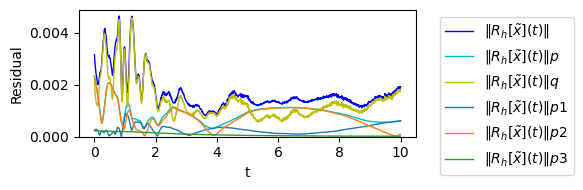

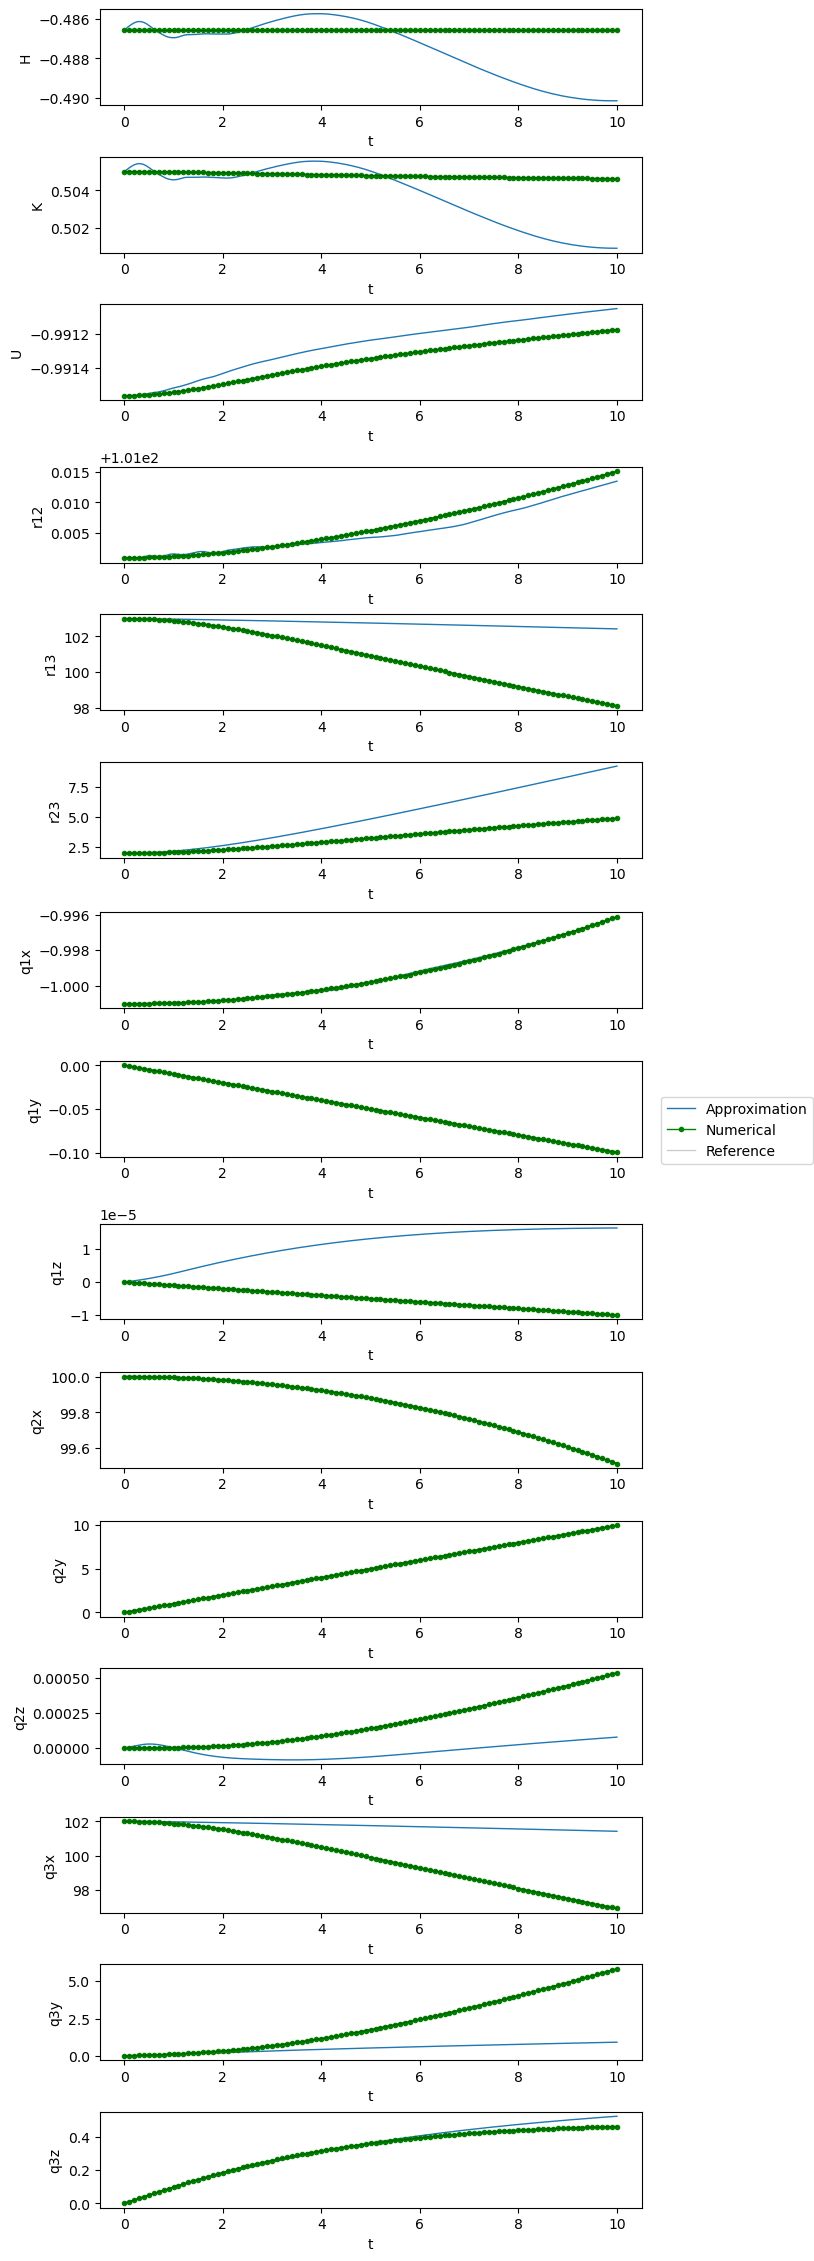

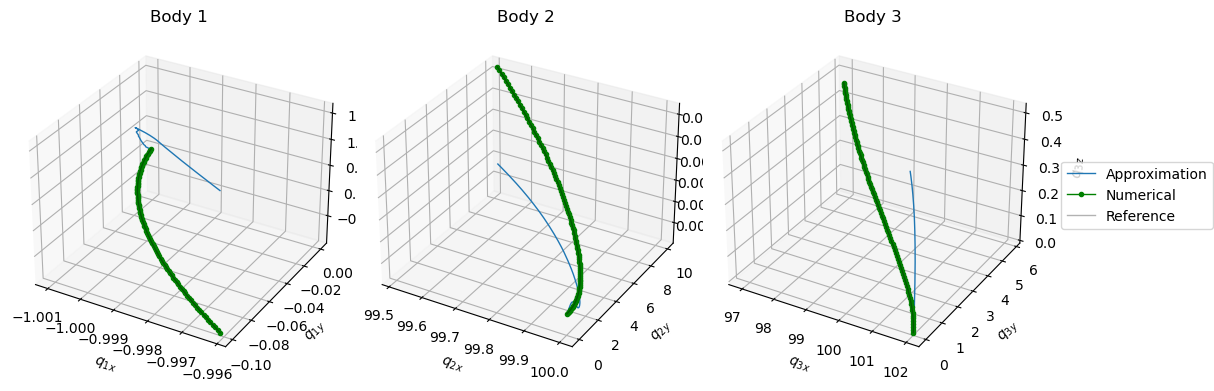

Approximation:


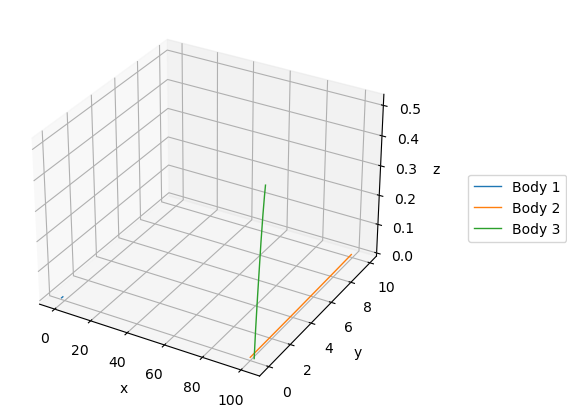

Reference:


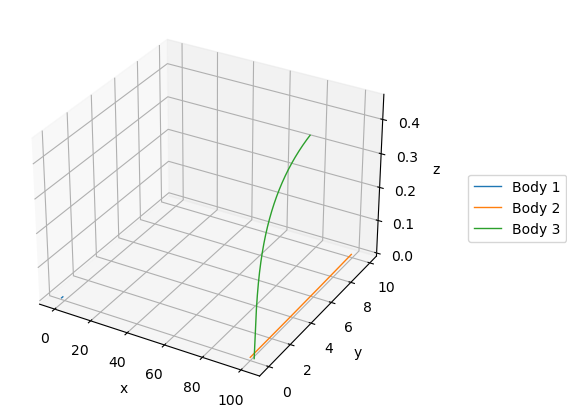

After alignment: 
	traj = ThreeBodyTrajectory(t_range=[0.0, 10.0], dt=0.009999999776482582, u0=[ 0.0000000e+00 -1.0001000e-02 -1.0000000e-06  0.0000000e+00
  1.0000000e+00  0.0000000e+00  0.0000000e+00  9.9999994e-02
  9.9999994e-02 -1.0010200e+00  0.0000000e+00  0.0000000e+00
  1.0000000e+02  0.0000000e+00  0.0000000e+00  1.0200000e+02
  0.0000000e+00  0.0000000e+00], states=States(problem=ThreeBody(m1=100.0, m2=1.0, m3=0.001, G=1.0), shape=(1001, 18)))
	ref_traj = ThreeBodyTrajectory(t_range=[0.0, 10.0], dt=0.01, u0=[ 0.00000e+00 -1.00010e-02 -1.00000e-06  0.00000e+00  1.00000e+00
  0.00000e+00  0.00000e+00  1.00000e-01  1.00000e-01 -1.00102e+00
  0.00000e+00  0.00000e+00  1.00000e+02  0.00000e+00  0.00000e+00
  1.02000e+02  0.00000e+00  0.00000e+00], states=States(problem=ThreeBody(m1=100.0, m2=1.0, m3=0.001, G=1.0), shape=(1001, 18)))


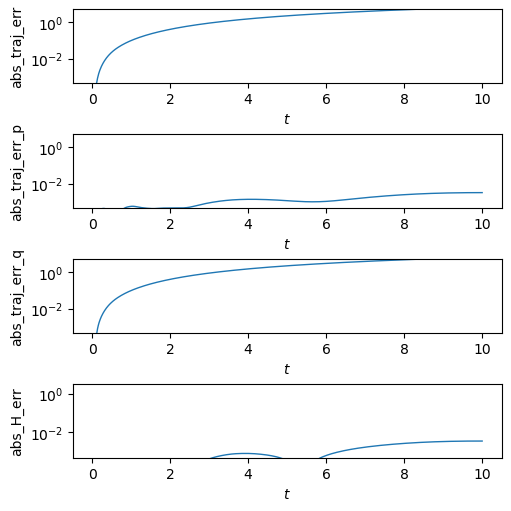

After alignment: 
	traj = ThreeBodyTrajectory(t_range=[0.0, 10.0], dt=0.009999999776482582, u0=[ 0.0000000e+00 -1.0001000e-02 -1.0000000e-06  0.0000000e+00
  1.0000000e+00  0.0000000e+00  0.0000000e+00  9.9999994e-02
  9.9999994e-02 -1.0010200e+00  0.0000000e+00  0.0000000e+00
  1.0000000e+02  0.0000000e+00  0.0000000e+00  1.0200000e+02
  0.0000000e+00  0.0000000e+00], states=States(problem=ThreeBody(m1=100.0, m2=1.0, m3=0.001, G=1.0), shape=(1001, 18)))
	ref_traj = ThreeBodyTrajectory(t_range=[0.0, 10.0], dt=0.01, u0=[ 0.00000e+00 -1.00010e-02 -1.00000e-06  0.00000e+00  1.00000e+00
  0.00000e+00  0.00000e+00  1.00000e-01  1.00000e-01 -1.00102e+00
  0.00000e+00  0.00000e+00  1.00000e+02  0.00000e+00  0.00000e+00
  1.02000e+02  0.00000e+00  0.00000e+00], states=States(problem=ThreeBody(m1=100.0, m2=1.0, m3=0.001, G=1.0), shape=(1001, 18)))


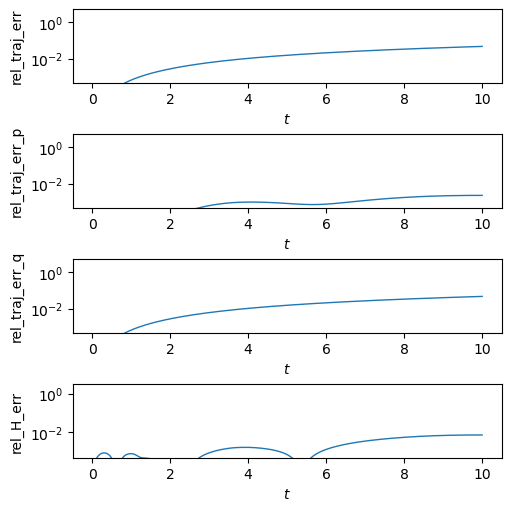

<Figure size 640x480 with 0 Axes>

In [24]:
eval_config = {
    "n_eval": 1000,
    "t_range": [0, 10],
    "show_numerical": True,
    "numerical_scheme": "velocity_verlet",
    "h": 0.1,
    "plot_error": True,
    "residual_ylim": [0, None],
    "traj_error_ylim": [5e-4, 5e0],
    "energy_error_ylim": [5e-4, 3e0]
}
test(model, problem_config, eval_config)

### Load trained model

In [42]:
T = 10.0
h = 0.1
strength_ODE = 1.0
strength_IC = 1.0
numerical_scheme = "velocity_verlet"
ODE_colloc_mode = "random3"

# filepath = f"./ckpts/T={T}_h={h}_ODE_{strength_ODE}_IC_{strength_IC}_ckpt.pt"
# filepath = f"./ckpts/{numerical_scheme}_{ODE_colloc_mode}_T={T}_h={h}_ODE_{strength_ODE}_IC_{strength_IC}_ckpt.pt"
filepath = "/workspace/projects_rui/learnsolnmap/notebooks/ckpts/velocity_verlet_balanced_random3_T=10.0_h=0.1_ODE_1.0_IC_1.0_ckpt.pt"
print("Load model from", filepath)
loaded_model = torch.load(filepath)
loaded_model.mult_w

Load model from /workspace/projects_rui/learnsolnmap/notebooks/ckpts/velocity_verlet_balanced_random3_T=10.0_h=0.1_ODE_1.0_IC_1.0_ckpt.pt


/tmp/ipykernel_561996/3705944536.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded_model = torch.load(filepath)


RuntimeError: PytorchStreamReader failed reading zip archive: failed finding central directory

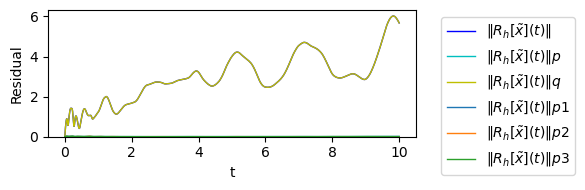

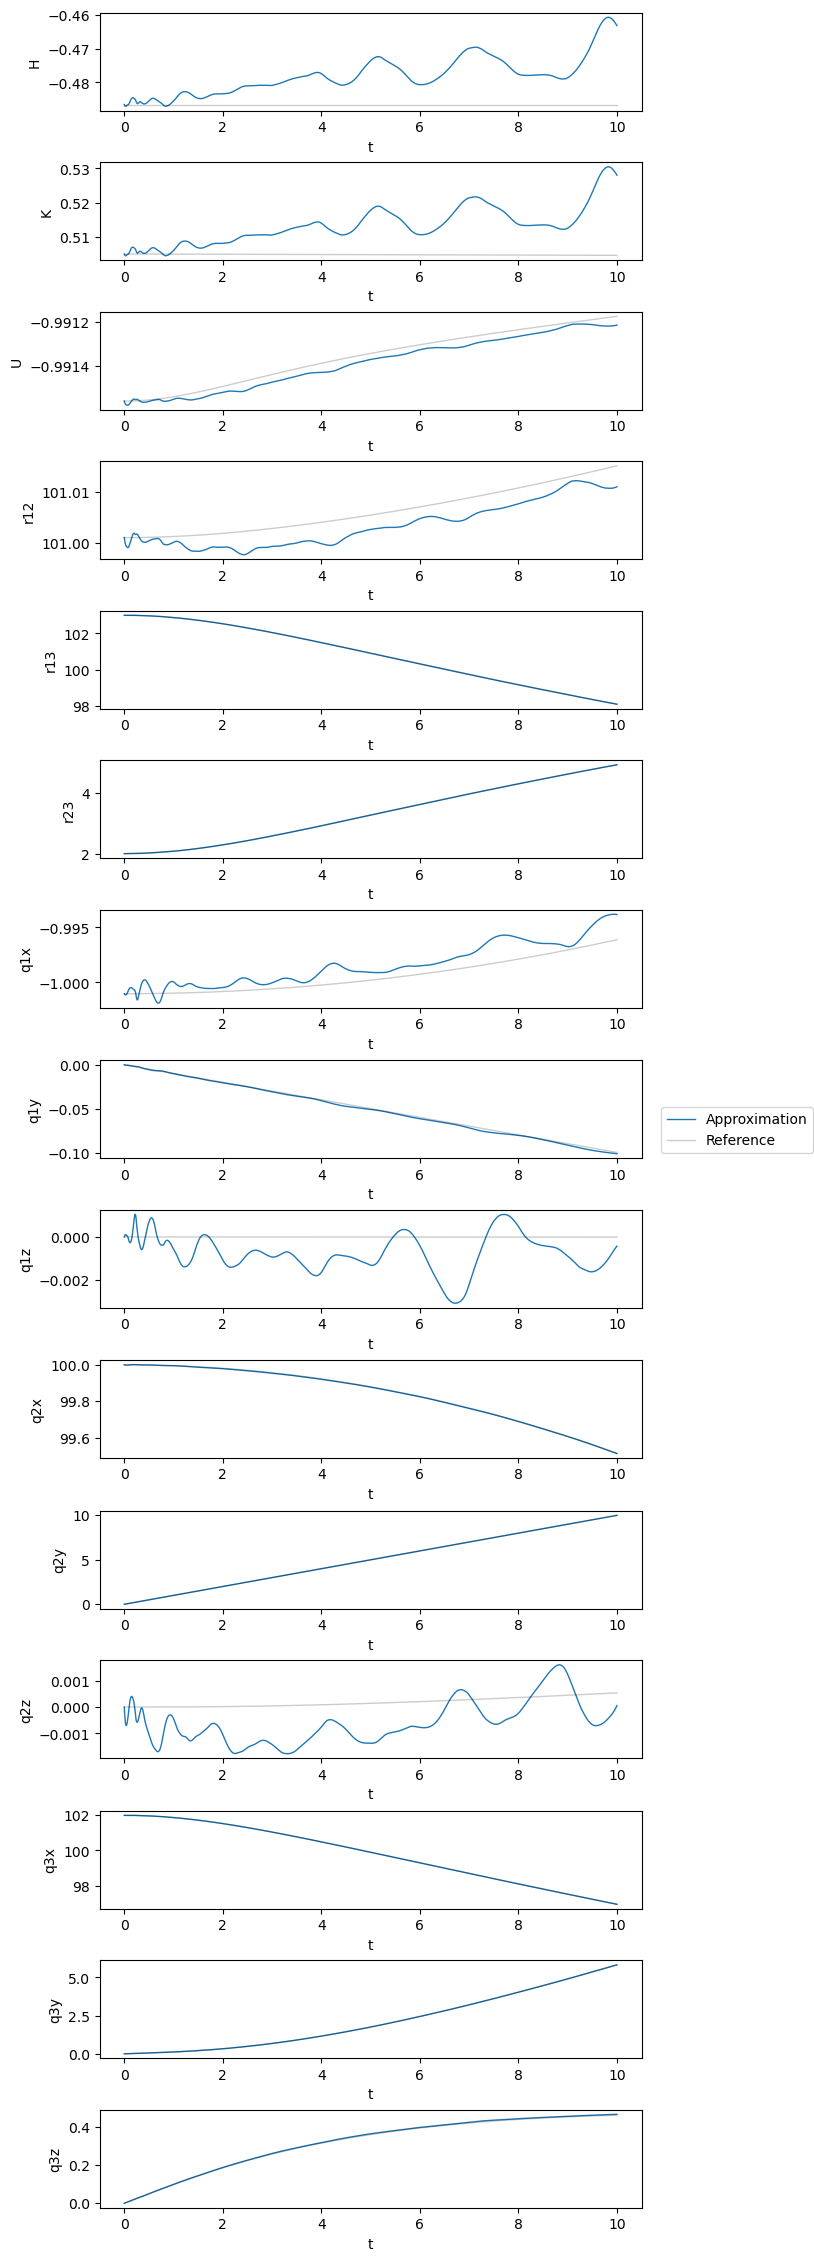

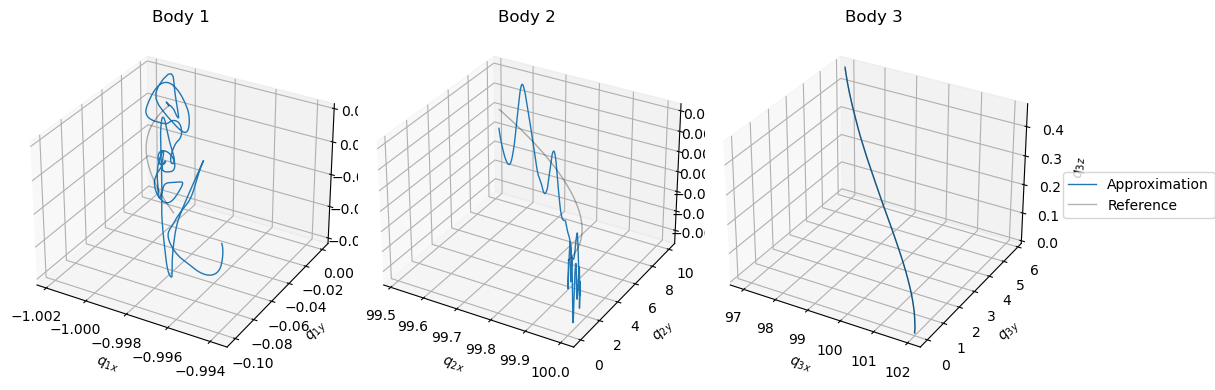

Approximation:


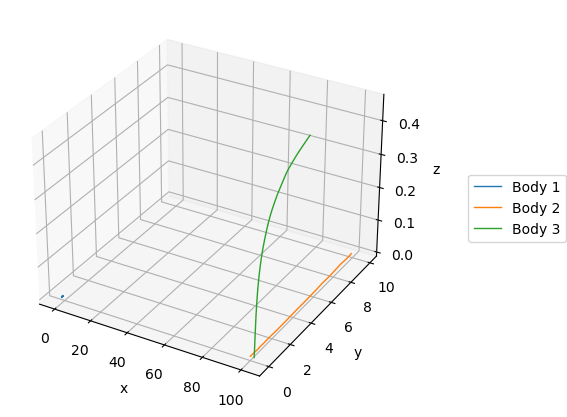

Reference:


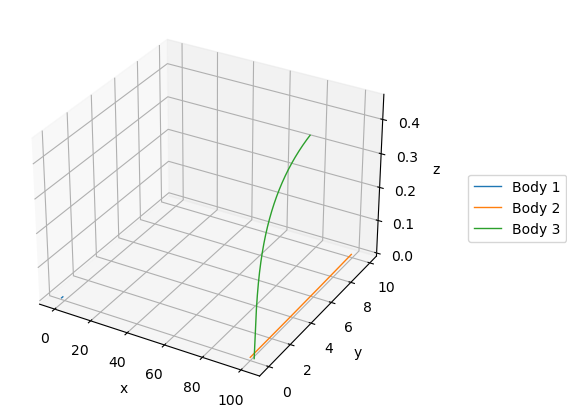

After alignment: 
	traj = ThreeBodyTrajectory(t_range=[0.0, 10.0], dt=0.009999999776482582, u0=[ 0.0000000e+00 -1.0001000e-02 -1.0000000e-06  0.0000000e+00
  1.0000000e+00  0.0000000e+00  0.0000000e+00  9.9999994e-02
  9.9999994e-02 -1.0010200e+00  0.0000000e+00  0.0000000e+00
  1.0000000e+02  0.0000000e+00  0.0000000e+00  1.0200000e+02
  0.0000000e+00  0.0000000e+00], states=States(problem=ThreeBody(m1=100.0, m2=1.0, m3=0.001, G=1.0), shape=(1001, 18)))
	ref_traj = ThreeBodyTrajectory(t_range=[0.0, 10.0], dt=0.01, u0=[ 0.00000e+00 -1.00010e-02 -1.00000e-06  0.00000e+00  1.00000e+00
  0.00000e+00  0.00000e+00  1.00000e-01  1.00000e-01 -1.00102e+00
  0.00000e+00  0.00000e+00  1.00000e+02  0.00000e+00  0.00000e+00
  1.02000e+02  0.00000e+00  0.00000e+00], states=States(problem=ThreeBody(m1=100.0, m2=1.0, m3=0.001, G=1.0), shape=(1001, 18)))


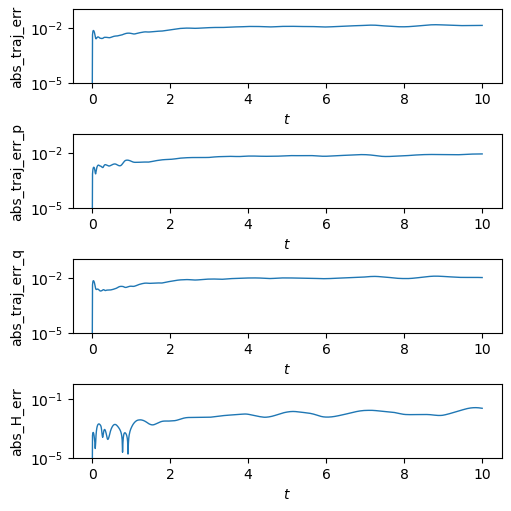

After alignment: 
	traj = ThreeBodyTrajectory(t_range=[0.0, 10.0], dt=0.009999999776482582, u0=[ 0.0000000e+00 -1.0001000e-02 -1.0000000e-06  0.0000000e+00
  1.0000000e+00  0.0000000e+00  0.0000000e+00  9.9999994e-02
  9.9999994e-02 -1.0010200e+00  0.0000000e+00  0.0000000e+00
  1.0000000e+02  0.0000000e+00  0.0000000e+00  1.0200000e+02
  0.0000000e+00  0.0000000e+00], states=States(problem=ThreeBody(m1=100.0, m2=1.0, m3=0.001, G=1.0), shape=(1001, 18)))
	ref_traj = ThreeBodyTrajectory(t_range=[0.0, 10.0], dt=0.01, u0=[ 0.00000e+00 -1.00010e-02 -1.00000e-06  0.00000e+00  1.00000e+00
  0.00000e+00  0.00000e+00  1.00000e-01  1.00000e-01 -1.00102e+00
  0.00000e+00  0.00000e+00  1.00000e+02  0.00000e+00  0.00000e+00
  1.02000e+02  0.00000e+00  0.00000e+00], states=States(problem=ThreeBody(m1=100.0, m2=1.0, m3=0.001, G=1.0), shape=(1001, 18)))


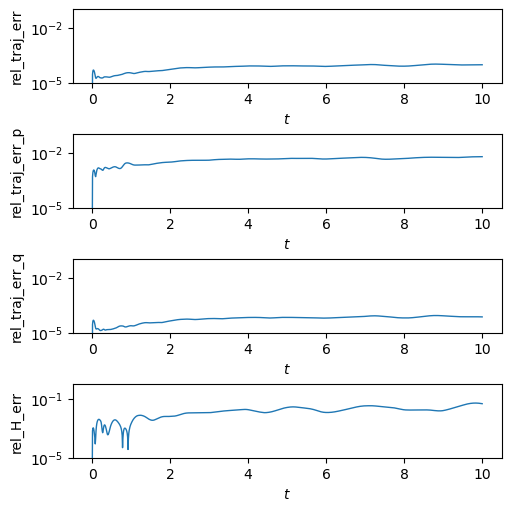

<Figure size 640x480 with 0 Axes>

In [26]:
problem_config = {
    "f": f_3body,
    "f1": f1_3body,
    "f2": f2_3body,
    "x_exact": None,
    "H": H_3body,
    "x0": ic_3body(),
    "ref_traj": ref_traj.select_between(0, 0.99)
}

eval_config = {
    "n_eval": 1000,
    "t_range": [0, 10],
    "show_numerical": False,
    "numerical_scheme": "velocity_verlet",
    "h": 0.1,
    "plot_error": True,
    "residual_ylim": [0, None],
    "traj_error_ylim": [1e-5, 1e-1],
    "energy_error_ylim": [1e-5, 1e0]
}
test(loaded_model, problem_config, eval_config)